# Previsão de situações de inadimplência por atraso no pagamento

## Task

O objetivo da equipe é construir um sistema que roda periodicamente, recebendo novas informações do cliente mês a mês. Queremos ser capazes de identificar, com antecedência, quais clientes têm maior probabilidade de não pagar uma determinada cobrança no prazo esperado, para construir ações de cobrança direcionadas, visando reduzir o índice de inadimplência de nosso stakeholder.

Para isso, iremos desenvolver um modelo preditivo que estime a **probabilidade de inadimplência** de cobranças mensais feitas aos clientes. Vamos gerar essas previsões para os registros na base de teste, que são as cobranças mais recentes da empresa que nos contratou para consultoria. 

Definimos inadimplência como um pagamento realizado com 5 ou mais dias de atraso em relação à data de vencimento.

Nas instruções de nosso contratante, está explícito que ele quer saber qual a probabilidade de inadimplência, não sendo necessário gerar uma classificação binária, portanto. 



## Bases de dados utilizadas 

Temos quatro bases de dados com informações sobre os clientes, seu comportamento mensal e os registros de pagamentos. Elas foram extraídas de um cenário de operação e se relacionam principalmente por duas chaves:

- ID_CLIENTE: identifica cada cliente de maneira única
- SAFRA_REF: representa o período de referência da cobrança

base_cadastral.csv contém informações de cadastro. Cada linha representa um cliente único (ID_CLIENTE). 

base_info.csv contém dados mensais como renda do mês anterior e número de funcionários. Cada linha representa um cliente em um determinado mês (ID_CLIENTE, SAFRA_REF).

base_pagamentos_desenvolvimento.csv contém o histórico de cobranças e pagamentos já realizados. Cada linha representa uma cobrança mensal para um cliente, com as dats de vencimento e pagamento disponíveis para construção da variável target (ID_CLIENTE, SAFRA_REF)

base_pagamentos_teste.csv: contém as cobranças mais recentes, para as quais devemos prever a probabilidade de inadimplência. Cada linha é uma cobrança mensal, sem informação de pagamento.



## Parte 1 - Tratamento inicial dos dados e EDA

Inicialmente, iniciaremos o projeto explorando um pouco os dados, para compreendê-los melhor e somente após isso construir nossa variável target e nossos modelos de previsão. Vamos precisar de algumas bibliotecas:

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

#configurações dos gráficos
sns.set_theme(style="whitegrid") 
plt.rcParams["figure.figsize"] = (10,6)

1. Carregando nossas bases de dados:

In [3]:
df_cadastral = pd.read_csv('data/base_cadastral.csv')
df_info = pd.read_csv('data/base_info.csv')
df_pag_dev = pd.read_csv("data/base_pagamentos_desenvolvimento.csv")
df_pag_teste = pd.read_csv('data/base_pagamentos_teste.csv')

In [4]:
print(df_cadastral.head())
print(df_info.head())
print(df_pag_dev.head())
print(df_pag_teste.head())

  ID_CLIENTE;DATA_CADASTRO;DDD;FLAG_PF;SEGMENTO_INDUSTRIAL;DOMINIO_EMAIL;PORTE;CEP_2_DIG
0  1661240395903230676;2013-08-22;99;;Serviços;YA...                                    
1  8274986328479596038;2017-01-25;31;;Comércio;YA...                                    
2  345447888460137901;2000-08-15;75;;Serviços;HOT...                                    
3  1003144834589372198;2017-08-06;49;;Serviços;OU...                                    
4  324916756972236008;2011-02-14;88;;Serviços;GMA...                                    
  ID_CLIENTE;SAFRA_REF;RENDA_MES_ANTERIOR;NO_FUNCIONARIOS
0               1661240395903230676;2018-09;16913.0;     
1         8274986328479596038;2018-09;106430.0;141.0     
2           345447888460137901;2018-09;707439.0;99.0     
3          1003144834589372198;2018-09;239659.0;96.0     
4          324916756972236008;2018-09;203123.0;103.0     
  ID_CLIENTE;SAFRA_REF;DATA_EMISSAO_DOCUMENTO;DATA_PAGAMENTO;DATA_VENCIMENTO;VALOR_A_PAGAR;TAXA
0  1661240395903230676

Vemos que o separados do csv na verdade era ; e não o padrão , então: 



In [5]:
df_cadastral = pd.read_csv('data/base_cadastral.csv', sep = ";")
df_info = pd.read_csv('data/base_info.csv', sep = ";")
df_pag_dev = pd.read_csv("data/base_pagamentos_desenvolvimento.csv", sep = ";")
df_pag_teste = pd.read_csv('data/base_pagamentos_teste.csv', sep = ";")

print(df_cadastral.head())
print(df_info.head())
print(df_pag_dev.head())
print(df_pag_teste.head())

            ID_CLIENTE DATA_CADASTRO DDD FLAG_PF SEGMENTO_INDUSTRIAL  \
0  1661240395903230676    2013-08-22  99     NaN            Serviços   
1  8274986328479596038    2017-01-25  31     NaN            Comércio   
2   345447888460137901    2000-08-15  75     NaN            Serviços   
3  1003144834589372198    2017-08-06  49     NaN            Serviços   
4   324916756972236008    2011-02-14  88     NaN            Serviços   

  DOMINIO_EMAIL    PORTE CEP_2_DIG  
0         YAHOO  PEQUENO        65  
1         YAHOO    MEDIO        77  
2       HOTMAIL  PEQUENO        48  
3       OUTLOOK  PEQUENO        89  
4         GMAIL   GRANDE        62  
            ID_CLIENTE SAFRA_REF  RENDA_MES_ANTERIOR  NO_FUNCIONARIOS
0  1661240395903230676   2018-09             16913.0              NaN
1  8274986328479596038   2018-09            106430.0            141.0
2   345447888460137901   2018-09            707439.0             99.0
3  1003144834589372198   2018-09            239659.0             

Podemos melhorar a visualização usando a função display do módulo IPython.display e passando um dicionário para printar as 4 bases de dados de uma vez só, ao invés de repetir a função print em 4 linhas seguidas. 

In [6]:
from IPython.display import display

dfs = {
    "Cadastral": df_cadastral,
    "Info": df_info,
    "Pagamentos Desenvolvimento": df_pag_dev,
    "Pagamentos Teste": df_pag_teste,
}

for nome, df in dfs.items():
    print(f"\n{nome}")
    display(df.head())


Cadastral


,ID_CLIENTE,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG
0,1661240395903230676,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
1,8274986328479596038,2017-01-25,31,NaN,Comércio,YAHOO,MEDIO,77
2,345447888460137901,2000-08-15,75,NaN,Serviços,HOTMAIL,PEQUENO,48
3,1003144834589372198,2017-08-06,49,NaN,Serviços,OUTLOOK,PEQUENO,89
4,324916756972236008,2011-02-14,88,NaN,Serviços,GMAIL,GRANDE,62



Info


,ID_CLIENTE,SAFRA_REF,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
0,1661240395903230676,2018-09,16913.0,NaN
1,8274986328479596038,2018-09,106430.0,141.0
2,345447888460137901,2018-09,707439.0,99.0
3,1003144834589372198,2018-09,239659.0,96.0
4,324916756972236008,2018-09,203123.0,103.0



Pagamentos Desenvolvimento


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99



Pagamentos Teste


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.75,4.99
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.50,5.99
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.50,5.99
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.00,5.99
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.95,6.99


2. Com nossas bases carregadas, o ideal é verificar se as chaves primárias e compostas informadas no dicionário garantem a unicidade das linhas, para termos segurança no momento de treinar nossos modelos de previsão. Vamos fazer um bloco de teste abaixo:

In [7]:
# Cadastral: Esperado 1 linha por ID_CLIENTE
duplicados_cadastral = df_cadastral.duplicated(subset=['ID_CLIENTE']).sum()
print(f"Duplicatas na base Cadastral (ID_CLIENTE): {duplicados_cadastral}")
if duplicados_cadastral > 0:
    print("ALERTA: Existem clientes duplicados na base cadastral. Necessário investigar e remover (ex: manter o cadastro mais recente).")

# Info: Esperado 1 linha por (ID_CLIENTE, SAFRA_REF)
duplicados_info = df_info.duplicated(subset=['ID_CLIENTE', 'SAFRA_REF']).sum()
print(f"Duplicatas na base Info (ID_CLIENTE + SAFRA_REF): {duplicados_info}")
if duplicados_info > 0:
    print("ALERTA: O mesmo cliente possui mais de um registro de renda/funcionários no mesmo mês.")

# Pagamentos: Múltiplas transações permitidas. Vamos ver qual o máximo de transações de um cliente na mesma safra.
transacoes_por_cliente_safra = df_pag_dev.groupby(['ID_CLIENTE', 'SAFRA_REF']).size()
print(f"Máximo de transações para um único cliente na mesma safra: {transacoes_por_cliente_safra.max()}")

Duplicatas na base Cadastral (ID_CLIENTE): 0
Duplicatas na base Info (ID_CLIENTE + SAFRA_REF): 0
Máximo de transações para um único cliente na mesma safra: 91


Vemos que não há duplicatas indesejadas e já sabemos que o cliente com mais transações realizou 91 na mesma safra. Vamos para o próximo passo, que é checar a consistência temporal dos dados, pois datas erradas acabariam com nossa capacidade de previsão probabilistítica de variáveis temporais.

3. Para verificar as informações temporais, vamos usar o bloco de código abaixo:

In [8]:
# convertendo colunas de datas para datetime 

cols_datas = ['DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO', 'DATA_PAGAMENTO']
for col in cols_datas:
    df_pag_dev[col] = pd.to_datetime(df_pag_dev[col], errors='coerce') #coerce transforma erros em NaT, evitando que o código quebre 

cols_datas_teste = ['DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO']
for col in cols_datas_teste:
    df_pag_teste[col] = pd.to_datetime(df_pag_teste[col], errors='coerce')

df_cadastral['DATA_CADASTRO'] = pd.to_datetime(df_cadastral['DATA_CADASTRO'], errors='coerce')

df_info['SAFRA_REF'] = pd.to_datetime(df_info['SAFRA_REF'], errors='coerce')
df_pag_dev['SAFRA_REF'] = pd.to_datetime(df_pag_dev['SAFRA_REF'], errors='coerce')
df_pag_teste['SAFRA_REF'] = pd.to_datetime(df_pag_teste['SAFRA_REF'], errors='coerce')

#confirmando se funcionou

print(df_cadastral[['DATA_CADASTRO']].dtypes)
print(df_pag_dev[['DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO', 'DATA_PAGAMENTO']].dtypes)
print(df_pag_teste[['DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO']].dtypes)


#Precisamos testar se não perdemos muita informação ao passar errors = coerce

bases_datas = {
    "Cadastral": (df_cadastral, ['DATA_CADASTRO']),
    "Info": (df_info, ['SAFRA_REF']),
    "Pagamentos Dev": (df_pag_dev, ['SAFRA_REF', 'DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO', 'DATA_PAGAMENTO']),
    "Pagamentos Teste": (df_pag_teste, ['SAFRA_REF', 'DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO'])
}

# Loop para calcular e imprimir os nulos de forma automatizada
for nome_base, (df, colunas) in bases_datas.items():
    print(f"\n[{nome_base}] (Total de linhas: {len(df)})")
    
    for col in colunas:
        if col in df.columns:
            nulos = df[col].isna().sum()
            percentual = (nulos / len(df)) * 100
            
            # Destacando visualmente se houver muitos nulos
            alerta = "Perda elevada de informação" if percentual > 0 else ""
            print(f" - {col}: {nulos} nulos ({percentual:.2f}%){alerta}")



DATA_CADASTRO    datetime64[ns]
dtype: object
DATA_EMISSAO_DOCUMENTO    datetime64[ns]
DATA_VENCIMENTO           datetime64[ns]
DATA_PAGAMENTO            datetime64[ns]
dtype: object
DATA_EMISSAO_DOCUMENTO    datetime64[ns]
DATA_VENCIMENTO           datetime64[ns]
dtype: object

[Cadastral] (Total de linhas: 1315)
 - DATA_CADASTRO: 0 nulos (0.00%)

[Info] (Total de linhas: 24401)
 - SAFRA_REF: 0 nulos (0.00%)

[Pagamentos Dev] (Total de linhas: 77414)
 - SAFRA_REF: 0 nulos (0.00%)
 - DATA_EMISSAO_DOCUMENTO: 0 nulos (0.00%)
 - DATA_VENCIMENTO: 0 nulos (0.00%)
 - DATA_PAGAMENTO: 0 nulos (0.00%)

[Pagamentos Teste] (Total de linhas: 12275)
 - SAFRA_REF: 0 nulos (0.00%)
 - DATA_EMISSAO_DOCUMENTO: 0 nulos (0.00%)
 - DATA_VENCIMENTO: 0 nulos (0.00%)


Ótimo! Não há nulos, então podemos continuar trabalhando com tranquilidade com nossas informações até aqui. Agora, vamos mapear a cobertura das Safras temporais, pois depois iremos fazer um particionamento de treino e teste. Isso será abordado em detalhes quando estivermos na parte de modelagem do nosso relatório.

In [9]:
def mapear_safras(df, nome_base):
    if 'SAFRA_REF' in df.columns:
        safras = df['SAFRA_REF'].value_counts().sort_index()
        print(f"Base {nome_base}: De {safras.index.min()} a {safras.index.max()} ({len(safras)} safras distintas)")
    else:
        print(f"Base {nome_base} não possui SAFRA_REF.")

mapear_safras(df_info, "Info")
mapear_safras(df_info, "Pagamentos Dev")
mapear_safras(df_info, "Pagamentos Teste")

Base Info: De 2018-09-01 00:00:00 a 2021-12-01 00:00:00 (40 safras distintas)
Base Pagamentos Dev: De 2018-09-01 00:00:00 a 2021-12-01 00:00:00 (40 safras distintas)
Base Pagamentos Teste: De 2018-09-01 00:00:00 a 2021-12-01 00:00:00 (40 safras distintas)


Vemos que a janela temporal é a mesma para as três bases de dados. Na documentação, estava escrito "contém as cobranças mais recentes, para as
quais o modelo deve prever a probabilidade de inadimplência. Cada linha representa uma cobrança mensal, sem a informação de pagamento." O nosso teste, no entanto, apontou para outra direção. Portanto, o teste não será feito "no futuro" em relação ao desenvolvimento. Provavelmente, o corte foi por amostra aleatória ou por clientes específicos dentro do mesmo período histórico. Se um mesmo cliente estiver na base de desenvolvimento e na de teste, o modelo pode overfittar. Portanto, vamos precisar rodar um teste de intersecção:

In [10]:
clientes_dev = set(df_pag_dev['ID_CLIENTE'].unique())
clientes_teste = set(df_pag_teste['ID_CLIENTE'].unique())

clientes_em_comum = clientes_dev.intersection(clientes_teste)

print(f"Total de clientes únicos no Treino (Dev): {len(clientes_dev)}")
print(f"Total de clientes únicos no Teste: {len(clientes_teste)}")
print(f"Clientes que estão EM AMBAS as bases: {len(clientes_em_comum)}")

if len(clientes_em_comum) > 0:
    percentual_vazamento = (len(clientes_em_comum) / len(clientes_teste)) * 100
    print(f"\n ALERTA: {percentual_vazamento:.2f}% dos clientes de Teste já aparecem no Treino!")
    print("Estratégia de Validação: Precisaremos usar StratifiedGroupKFold (agrupando por ID_CLIENTE) para evitar que o modelo decore os clientes.")
else:
    print("\n CENÁRIO IDEAL: As bases têm clientes completamente diferentes (Out-of-Sample).")
    print("Estratégia de Validação: Podemos usar validação cruzada tradicional K-Fold estratificada pelo Target.")

Total de clientes únicos no Treino (Dev): 1248
Total de clientes únicos no Teste: 976
Clientes que estão EM AMBAS as bases: 888

 ALERTA: 90.98% dos clientes de Teste já aparecem no Treino!
Estratégia de Validação: Precisaremos usar StratifiedGroupKFold (agrupando por ID_CLIENTE) para evitar que o modelo decore os clientes.


A validação por StratifiedGroupKFold garante que todas as linhas referentes a um mesmo ID_CLIENTE fiquem juntas no mesmo fold, ou seja, ou o cliente é 100% usado para treinar, ou é 100% usado para testar, nunca para ambos. Isso evita que o modelo memorize o comportamento de um cliente específico, pois isso o deixaria ruim em generalizar em dados que ele nunca viu depois. Ao prever a inadimplência da base de vaildação, o modelo estará lidando exclusivamente com clientes que ele não viu durante o treino, forçando o algoritmo a encontrar padrões reais em vez de puxar o histórico vazado de um cliente específico. 

Com aproximadamente 91% dos clientes do teste já conhecidos pelo treino, nossa modelagem deve ter como objetivo medir **a probabilidade de um cliente que já é da carteira atrasar os pagamentos**, e não se o modelo generaliza para novos clientes. A partir disso, precisamos olhar para o comportamento histórico dos clientes para poder prever o comportamento futuro deles. 

4. Agora, vamos definir o nosso target:

In [11]:
df_pag_dev['DIAS_ATRASO'] = (df_pag_dev['DATA_PAGAMENTO'] - df_pag_dev['DATA_VENCIMENTO']).dt.days

# Regra de negócio: Um pagamento é considerado inadimplente se for realizado com 5 dias ou mais de atraso.
df_pag_dev['TARGET_INADIMPLENCIA'] = (df_pag_dev['DIAS_ATRASO'] >= 5).astype(int)

taxa_inadimplencia = df_pag_dev['TARGET_INADIMPLENCIA'].mean() * 100
print(f"Taxa geral de inadimplência na base de desenvolvimento: {taxa_inadimplencia:.2f}%\n")


Taxa geral de inadimplência na base de desenvolvimento: 7.02%



Como estamos lidando com um problema de classificação (queremos prever a probabilidade exata de uma cobrança mensal ser inadimplente), nosso target é uma variável binária que recebe 1, quando o pagamento está atrasado a 5 ou mais dias, e 0, quando não está atrasado ou está atrasado em até 5 dias.

5. Vamos fazer uma breve análise exploratória antes de partir para a modelagem, pois isso pode nos gerar insights para tomar decisões de engenharia de features e também porque auxilia na interpretabilidade de nossos resultados.

Aproveitamos esse mesmo cruzamento de bases para já incorporar a `base_info` (renda do mês anterior e número de funcionários), que foi descrita na introdução como uma das quatro bases principais, mas que ainda não havia sido unida às demais.


C:\Users\pegte\AppData\Local\Temp\ipykernel_31024\2827154923.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_completo, x='PORTE', y='TARGET_INADIMPLENCIA', order=ordem_porte, errorbar=None, palette="viridis")


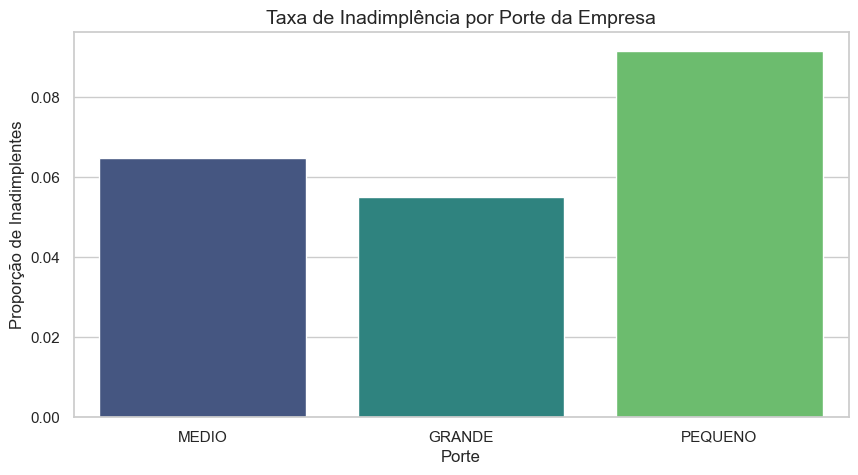

C:\Users\pegte\AppData\Local\Temp\ipykernel_31024\2827154923.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_completo, x='TIPO_PESSOA', y='TARGET_INADIMPLENCIA', errorbar=None, palette="muted")


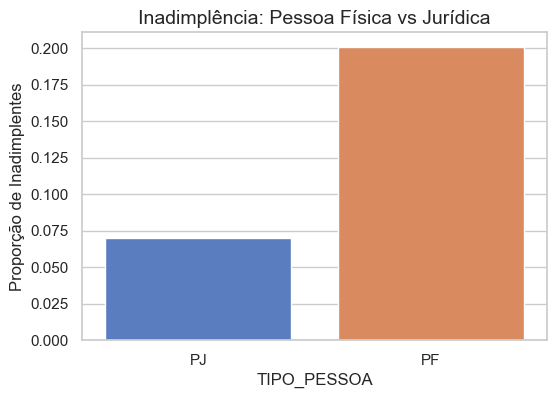

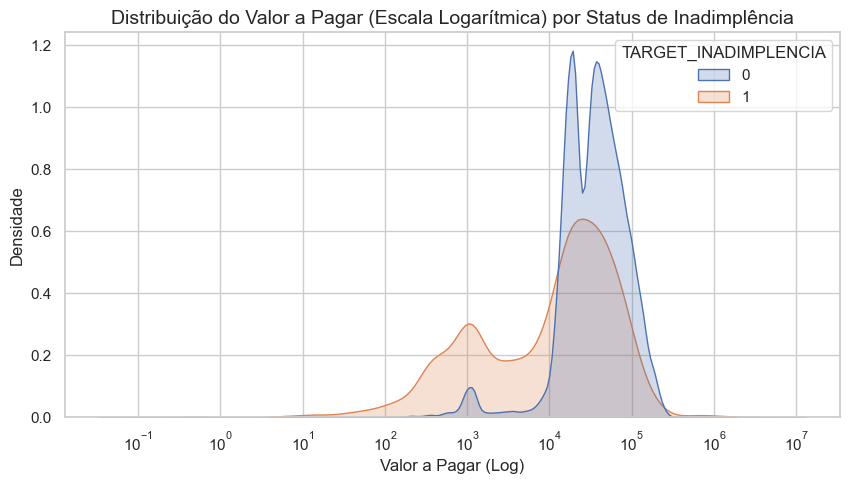

In [12]:
# Join com Base Cadastral e Base Info para Análise Exploratória e para o modelo
# (a base_info tem RENDA_MES_ANTERIOR e NO_FUNCIONARIOS, que também são preditores relevantes
# de risco de crédito e vão virar features do modelo mais adiante)
df_completo = df_pag_dev.merge(df_cadastral, on='ID_CLIENTE', how='left')
df_completo = df_completo.merge(df_info, on=['ID_CLIENTE', 'SAFRA_REF'], how='left')

# Gráfico 1: Inadimplência por Porte da Empresa
plt.figure(figsize=(10, 5))
ordem_porte = df_completo['PORTE'].value_counts().index
sns.barplot(data=df_completo, x='PORTE', y='TARGET_INADIMPLENCIA', order=ordem_porte, errorbar=None, palette="viridis")
plt.title('Taxa de Inadimplência por Porte da Empresa', fontsize=14)
plt.ylabel('Proporção de Inadimplentes', fontsize=12)
plt.xlabel('Porte', fontsize=12)
plt.show()

# Gráfico 2: Inadimplência por Tipo de Pessoa (Física vs Jurídica)
# Tratando os NaNs da FLAG_PF (conforme dicionário, NaN = Pessoa Jurídica)
df_completo['TIPO_PESSOA'] = df_completo['FLAG_PF'].fillna('PJ').replace('X', 'PF')

plt.figure(figsize=(6, 4))
sns.barplot(data=df_completo, x='TIPO_PESSOA', y='TARGET_INADIMPLENCIA', errorbar=None, palette="muted")
plt.title('Inadimplência: Pessoa Física vs Jurídica', fontsize=14)
plt.ylabel('Proporção de Inadimplentes', fontsize=12)
plt.show()

# Gráfico 3: Distribuição do Valor a Pagar (Target 0 vs Target 1)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_completo, x='VALOR_A_PAGAR', hue='TARGET_INADIMPLENCIA', log_scale=True, common_norm=False, fill=True)
plt.title('Distribuição do Valor a Pagar (Escala Logarítmica) por Status de Inadimplência', fontsize=14)
plt.xlabel('Valor a Pagar (Log)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.show()


Vemos que:

- Quanto maior o tamanho da empresa, menor a proporção de inadimplentes.
- Pessoas físicas devem mais que pessoas jurídicas.
- Entre 10^2 e 10^3 a curva de inadimplência é maior do que a de adimplentes, indicando que faturas mais baratas têm uma taxa de atraso/calote maior.
- O grande volume de operações está seguro, sendo de ticket alto e com boa parte sendo paga em dia. A curva laranja também sobe, mas o volume de bons pagadores supera os maus pagadores com folga.
- Há dois perfis de inadimplência: calotes de ticket baixo, que podem ser oriundos de desorganização, esquecimento ou um perfil de cliente menor com fluxo de caixa mais frágil e calotes de ticket alto, nos quais provavelmente estamos falando de empresas maiores que entraram em dificuldades financeiras mais severas, já que os valores são mais elevados.

Podemos cruzar a variável target com os perfis, para verificar se nossas hipóteses se sustentam:

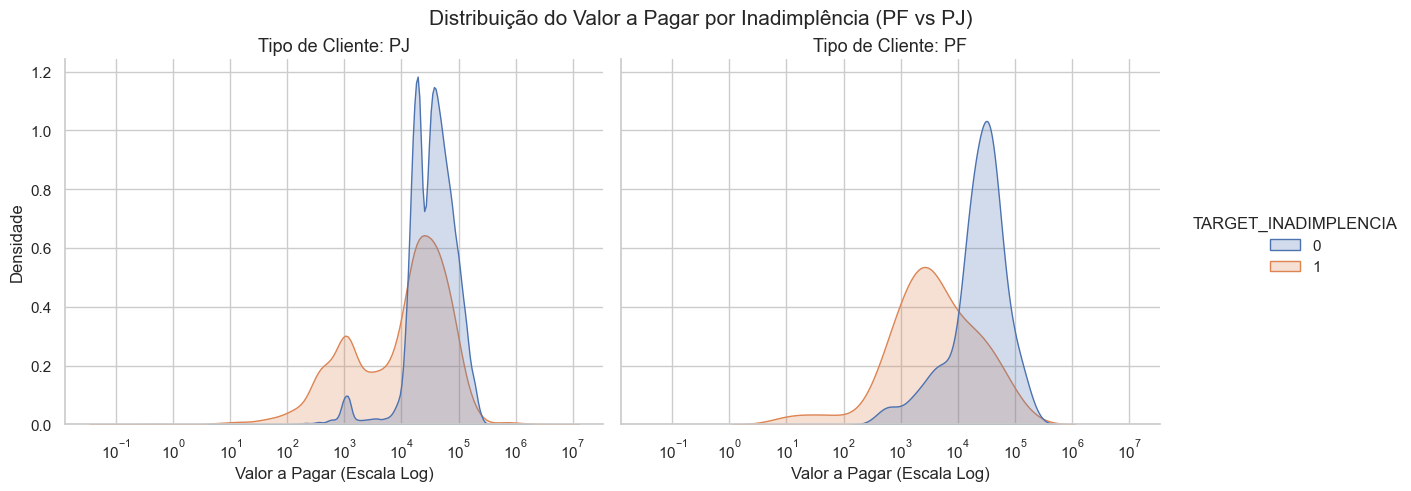

In [13]:
# Criação de um gráfico KDE com painéis separados por 'TIPO_PESSOA'
g = sns.displot(
    data=df_completo, 
    x='VALOR_A_PAGAR', 
    hue='TARGET_INADIMPLENCIA', 
    col='TIPO_PESSOA',      # Esta é a mágica que separa PF de um lado e PJ do outro
    kind='kde',             # Mantém o estilo de curva de densidade
    log_scale=True,         # Mantém a escala logarítmica no eixo X
    common_norm=False,      # Normaliza a área de cada curva independentemente
    fill=True,
    height=5, 
    aspect=1.2              # Controla a largura de cada subgráfico
)

# Ajustes de formatação e títulos
g.set_axis_labels('Valor a Pagar (Escala Log)', 'Densidade')
g.set_titles(col_template="Tipo de Cliente: {col_name}", size=13)
g.fig.suptitle('Distribuição do Valor a Pagar por Inadimplência (PF vs PJ)', fontsize=15)
g.fig.subplots_adjust(top=0.88)

plt.show()

Vemos que, de fato, os calotes de pessoas jurídicas estão concentrados em tickets mais altos (~10.000 a 100.000) e de pessoas físicas em tickets mais baixos (~1.000). Isso implica que nosso modelo provavelmente capturará essa relação e levará isso em conta no cálculo das probabilidades. 

6. Agora, vamos preparar nossa base de dados que será utilizada na modelagem:

In [14]:
df_modelagem = df_completo.copy()
df_modelagem.rename(columns={'TARGET_INADIMPLENCIA' : 'TARGET'}, inplace=True) #Renomeamos para somente TARGET 
df_modelagem.head()

# Criação de variáveis históricas do cliente 
# ordenamos tudo cronologicamente, para que o passado mais distante fique nas linhas de cima e o mais atuais fiquem mais para trás, simulando a linha do tempo exata de acontecimento das emissões

df_modelagem = df_modelagem.sort_values(by=['ID_CLIENTE', 'DATA_EMISSAO_DOCUMENTO']).reset_index(drop=True)
df_modelagem.head()

# cria histórico de inadimplência acumulada, agrupando por cliente e usando shift(1) para não incluir o TARGET da fatura atual, evitando vazamento dos dados
df_modelagem['HISTORICO_INADIMPLENCIA'] = (
    df_modelagem.groupby('ID_CLIENTE')['TARGET']
    .apply(lambda x: x.shift(1).expanding().sum())
    .reset_index(level=0, drop=True)
    .fillna(0) # se é a primeira fatura, o histórico é 0
)

# cria a variável do total de faturas anteriores
df_modelagem['QTD_FATURAS_ANTERIORES'] = (
    df_modelagem.groupby('ID_CLIENTE')['TARGET']
    .apply(lambda x: x.shift(1).expanding().count())
    .reset_index(level=0, drop=True)
    .fillna(0) # premissa de negócio: se é a primeira compra do cliente, seu histórico de inadimplência é 0
) 
# usamos expanding para que o código não olhe apenas para a última fatura, mas crie uma janela que cresça a cada linha, ou seja, na 2a fatura, olha para 1 fatura passada, na 10a, olha para as 9 anteriores.
# isso permite que o modelo diferencie um cliente que atrasou uma de duas faturas de um que atrasou uma de cinquenta faturas

# cria a taxa de inadimplência histórica do cliente (%)
# evitamos divisão por zero usando np.where
df_modelagem['TAXA_ATRASO_CLIENTE'] = np.where(
    df_modelagem['QTD_FATURAS_ANTERIORES'] > 0,
    df_modelagem['HISTORICO_INADIMPLENCIA'] / df_modelagem['QTD_FATURAS_ANTERIORES'],
    0
)

# validando o resultado final
print("Amostra das features temporais criadas (10 primeiras linhas) e do dataframe completo:")
display(df_modelagem[['ID_CLIENTE', 'DATA_EMISSAO_DOCUMENTO', 'TARGET', 'HISTORICO_INADIMPLENCIA', 'TAXA_ATRASO_CLIENTE']].head(10))
display(df_modelagem)

Amostra das features temporais criadas (10 primeiras linhas) e do dataframe completo:


,ID_CLIENTE,DATA_EMISSAO_DOCUMENTO,TARGET,HISTORICO_INADIMPLENCIA,TAXA_ATRASO_CLIENTE
0,8784237149961904,2018-08-17,0,0.0,0.0
1,8784237149961904,2018-08-22,0,0.0,0.0
2,8784237149961904,2018-08-23,0,0.0,0.0
3,8784237149961904,2018-08-23,0,0.0,0.0
4,8784237149961904,2018-08-24,0,0.0,0.0
5,8784237149961904,2018-09-04,0,0.0,0.0
6,8784237149961904,2018-09-06,0,0.0,0.0
7,8784237149961904,2018-09-09,0,0.0,0.0
8,8784237149961904,2018-09-11,0,0.0,0.0
9,8784237149961904,2018-09-17,0,0.0,0.0


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,DIAS_ATRASO,TARGET,DATA_CADASTRO,...,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS,TIPO_PESSOA,HISTORICO_INADIMPLENCIA,QTD_FATURAS_ANTERIORES,TAXA_ATRASO_CLIENTE
0,8784237149961904,2018-08-01,2018-08-17,2018-09-04,2018-09-04,100616.10,5.99,0,0,2011-02-14,...,Comércio,HOTMAIL,PEQUENO,27,NaN,NaN,PJ,0.0,0.0,0.000000
1,8784237149961904,2018-08-01,2018-08-22,2018-09-11,2018-09-11,89552.80,5.99,0,0,2011-02-14,...,Comércio,HOTMAIL,PEQUENO,27,NaN,NaN,PJ,0.0,1.0,0.000000
2,8784237149961904,2018-08-01,2018-08-23,2018-09-10,2018-09-10,94062.80,5.99,0,0,2011-02-14,...,Comércio,HOTMAIL,PEQUENO,27,NaN,NaN,PJ,0.0,2.0,0.000000
3,8784237149961904,2018-08-01,2018-08-23,2018-09-08,2018-09-10,102686.10,5.99,-2,0,2011-02-14,...,Comércio,HOTMAIL,PEQUENO,27,NaN,NaN,PJ,0.0,3.0,0.000000
4,8784237149961904,2018-08-01,2018-08-24,2018-09-11,2018-09-11,51393.00,5.99,0,0,2011-02-14,...,Comércio,HOTMAIL,PEQUENO,27,NaN,NaN,PJ,0.0,4.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77409,9206030810342980458,2021-05-01,2021-05-16,2021-06-01,2021-06-01,107321.36,11.99,0,0,2005-08-08,...,Serviços,HOTMAIL,MEDIO,91,256133.0,109.0,PJ,2.0,99.0,0.020202
77410,9206030810342980458,2021-05-01,2021-05-23,2021-06-08,2021-06-08,38372.91,5.99,0,0,2005-08-08,...,Serviços,HOTMAIL,MEDIO,91,256133.0,109.0,PJ,2.0,100.0,0.020000
77411,9206030810342980458,2021-06-01,2021-06-16,2021-07-02,2021-07-02,43030.50,5.99,0,0,2005-08-08,...,Serviços,HOTMAIL,MEDIO,91,463963.0,105.0,PJ,2.0,101.0,0.019802
77412,9206030810342980458,2021-06-01,2021-06-18,2021-07-05,2021-07-05,107318.81,5.99,0,0,2005-08-08,...,Serviços,HOTMAIL,MEDIO,91,463963.0,105.0,PJ,2.0,102.0,0.019608


## Parte 2 - Machine Learning para classificação

Ainda precisamos fazer alguns ajustes antes de aplicar os algoritmos de Machine Learning para estimar de fato a probabilidade que queremos. Primeiro, precisamos remover algumas colunas para evitar que o modelo trapaceie (por vazamento dos dados). Também precisamos evitar que o modelo decore os dados e, além disso, precisamos adequar a formatação matemática. Para isso, vamos:

1. Remover as variáveis DATA_PAGAMENTO e DIAS_ATRASO, pois causam vazamento dos dados. Em produção, não temos essas variáveis no momento que temos que tomarmos a decisão de fazer uma cobrança proativa. A presença delas faria com que nosso modelo acertasse muito em teste, pois sempre que a coluna DIAS_ATRASO fosse maior que 0, o target seria 1, mas falhasse em dados novos.

2. Remover a variável ID_CLIENTE das features do modelo, pois ela é um identificador claro que os algoritmos aproveitariam para aprender padrões específicos de cada cliente, em vez de um padrão de risco generalizável. Porém, antes de removê-la definitivamente, vamos guardá-la à parte: como ~91% dos clientes de teste também aparecem no treino (visto na EDA), precisamos garantir que as linhas de um mesmo cliente fiquem inteiramente de um lado do split (treino, validação OU teste), nunca espalhadas entre os três — do contrário, o modelo teria uma prévia do comportamento do cliente durante o treino e as métricas de avaliação ficariam infladas de forma artificial. Por isso, ID_CLIENTE só será removido de X depois de servir como chave de agrupamento (`groups`) no split.

3. As variáveis SAFRA_REF, DATA_EMISSAO_DOCUMENTO, DATA_VENCIMENTO e DATA_CADASTRO precisam ser removidas pois os algoritmos não lidam bem com as datas por baixo dos panos. Elas já cumpriram seu papel quando usamos a emissão para ordenar nossos dados cronologicamente e criar a janela móvel de quantidade de faturas anteriores.

4. Tratar as variáveis categóricas


In [15]:
df_treino = df_modelagem.copy()

colunas_para_remover = [
    'SAFRA_REF',
    'DATA_EMISSAO_DOCUMENTO',
    'DATA_PAGAMENTO',
    'DATA_VENCIMENTO',
    'DATA_CADASTRO',
    'DIAS_ATRASO'
]
df_treino = df_treino.drop(columns=colunas_para_remover) # Removemos as colunas necessárias explicadas anteriormente

# IMPORTANTE: mantemos ID_CLIENTE por enquanto (não como feature, mas como chave de agrupamento).
# Ele será usado mais adiante para fazer um split treino/validação/teste agrupado por cliente, e só
# será removido de X depois de cumprir esse papel, evitando o vazamento de dados que ocorre quando
# o mesmo cliente aparece em conjuntos diferentes do split.

display(df_treino)


,ID_CLIENTE,VALOR_A_PAGAR,TAXA,TARGET,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS,TIPO_PESSOA,HISTORICO_INADIMPLENCIA,QTD_FATURAS_ANTERIORES,TAXA_ATRASO_CLIENTE
0,8784237149961904,100616.10,5.99,0,11,NaN,Comércio,HOTMAIL,PEQUENO,27,NaN,NaN,PJ,0.0,0.0,0.000000
1,8784237149961904,89552.80,5.99,0,11,NaN,Comércio,HOTMAIL,PEQUENO,27,NaN,NaN,PJ,0.0,1.0,0.000000
2,8784237149961904,94062.80,5.99,0,11,NaN,Comércio,HOTMAIL,PEQUENO,27,NaN,NaN,PJ,0.0,2.0,0.000000
3,8784237149961904,102686.10,5.99,0,11,NaN,Comércio,HOTMAIL,PEQUENO,27,NaN,NaN,PJ,0.0,3.0,0.000000
4,8784237149961904,51393.00,5.99,0,11,NaN,Comércio,HOTMAIL,PEQUENO,27,NaN,NaN,PJ,0.0,4.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77409,9206030810342980458,107321.36,11.99,0,11,NaN,Serviços,HOTMAIL,MEDIO,91,256133.0,109.0,PJ,2.0,99.0,0.020202
77410,9206030810342980458,38372.91,5.99,0,11,NaN,Serviços,HOTMAIL,MEDIO,91,256133.0,109.0,PJ,2.0,100.0,0.020000
77411,9206030810342980458,43030.50,5.99,0,11,NaN,Serviços,HOTMAIL,MEDIO,91,463963.0,105.0,PJ,2.0,101.0,0.019802
77412,9206030810342980458,107318.81,5.99,0,11,NaN,Serviços,HOTMAIL,MEDIO,91,463963.0,105.0,PJ,2.0,102.0,0.019608


In [16]:
# Precisamos transformar os NaNs em 0, do contrário, o modelo não conseguiria aproveitar esses dados. É o caso da variável FLAG_PF, sendo X se é pessoa física, 0 se jurídica
df_treino['FLAG_PF'] = df_treino['FLAG_PF'].fillna(0)

display(df_treino)

,ID_CLIENTE,VALOR_A_PAGAR,TAXA,TARGET,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS,TIPO_PESSOA,HISTORICO_INADIMPLENCIA,QTD_FATURAS_ANTERIORES,TAXA_ATRASO_CLIENTE
0,8784237149961904,100616.10,5.99,0,11,0,Comércio,HOTMAIL,PEQUENO,27,NaN,NaN,PJ,0.0,0.0,0.000000
1,8784237149961904,89552.80,5.99,0,11,0,Comércio,HOTMAIL,PEQUENO,27,NaN,NaN,PJ,0.0,1.0,0.000000
2,8784237149961904,94062.80,5.99,0,11,0,Comércio,HOTMAIL,PEQUENO,27,NaN,NaN,PJ,0.0,2.0,0.000000
3,8784237149961904,102686.10,5.99,0,11,0,Comércio,HOTMAIL,PEQUENO,27,NaN,NaN,PJ,0.0,3.0,0.000000
4,8784237149961904,51393.00,5.99,0,11,0,Comércio,HOTMAIL,PEQUENO,27,NaN,NaN,PJ,0.0,4.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77409,9206030810342980458,107321.36,11.99,0,11,0,Serviços,HOTMAIL,MEDIO,91,256133.0,109.0,PJ,2.0,99.0,0.020202
77410,9206030810342980458,38372.91,5.99,0,11,0,Serviços,HOTMAIL,MEDIO,91,256133.0,109.0,PJ,2.0,100.0,0.020000
77411,9206030810342980458,43030.50,5.99,0,11,0,Serviços,HOTMAIL,MEDIO,91,463963.0,105.0,PJ,2.0,101.0,0.019802
77412,9206030810342980458,107318.81,5.99,0,11,0,Serviços,HOTMAIL,MEDIO,91,463963.0,105.0,PJ,2.0,102.0,0.019608


In [17]:
# Agora, vamos avaliar para ver se temos que lidar com valores nulos:

nulos_abs = df_treino.isna().sum()
nulos_pct = (df_treino.isna().sum() / len(df_treino)) * 100

# Junta tudo em um DataFrame para facilitar a visualização
df_nulos = pd.DataFrame({
    'Quantidade Nulos': nulos_abs,
    'Percentual (%)': nulos_pct
})

# Filtra apenas as colunas que têm nulos e ordena da maior para a menor
df_nulos = df_nulos[df_nulos['Quantidade Nulos'] > 0].sort_values(by='Quantidade Nulos', ascending=False)

# Exibe o resultado do teste
if df_nulos.empty:
    print("Não há nenhum valor nulo no DataFrame")
else:
    print(f"Encontrados valores nulos em {len(df_nulos)} coluna(s).")
    display(df_nulos.round(2)) 

Encontrados valores nulos em 7 coluna(s).


,Quantidade Nulos,Percentual (%)
NO_FUNCIONARIOS,7587,9.80
DDD,7414,9.58
RENDA_MES_ANTERIOR,6132,7.92
PORTE,2476,3.20
SEGMENTO_INDUSTRIAL,1417,1.83
VALOR_A_PAGAR,1170,1.51
DOMINIO_EMAIL,898,1.16


Precisamos tratar essas 7 colunas que possuem dados nulos. Temos 4 casos possíveis e que nortearão nossa abordagem:

1. Nulos Estruturais de Negócios
 
 Provavelmente, esses 3% de nulos em porte e 1,8% em segmento industrial são clientes PF. Poderíamos, por exemplo, preencher com "Não se Aplica (PF"), mas antes, iremos rodar um teste para confirmar.

2. Em Valor a Pagar, faltam dados em 1,5% das linhas. Podemos ou preencher com 0 ou dropar essas linhas, visto que representam uma porcentagem bem baixa das observações. A primeira abordagem pode gerar ruído, pois o modelo pode entender que o valor a pagar é zero e tentar encontrar um padrão de inadimplência nisso. A segunda abordagem perde um pouco do volume de treino, mas garante que nosso modelo só vai aprender com dados íntegros. Vamos seguir, portanto, a segunda abordagem.

3. Para DDD e DOMINIO_EMAIL, estamos lidando com informações de contatos. Com quase 10% de nulos em DDD, não é viável abrir mão dessa informação para o treino. O caminho que vamos seguir aqui é preencher com "Sem_DDD" e "Sem_Email", para que o modelo leve em conta a relação entre não deixar contato e inadimplência.

4. RENDA_MES_ANTERIOR (7,92% de nulos) e NO_FUNCIONARIOS (9,80% de nulos) são as duas colunas novas que entraram na base quando unimos a `base_info` ao restante dos dados. Elas aparecem aqui porque essa base é reportada mês a mês e nem todo cliente tem os dois números preenchidos em todo período. Como são numéricas, preencher com 0 teria o mesmo problema do item 2 (pareceria "renda zero" ou "zero funcionários", o que não é real) — e a proporção de nulos aqui é grande demais para simplesmente dropar as linhas, como fizemos com VALOR_A_PAGAR. Por isso vamos: (a) criar uma flag binária indicando que o dado estava ausente naquele mês, preservando esse sinal (mesma lógica do item 3), e (b) preencher o valor em si com a mediana do treino.


In [18]:
# Filtra apenas as linhas onde 'PORTE' é nulo e conta os valores da coluna 'FLAG_PF'
nulos_porte = df_treino[df_treino['PORTE'].isna()]['FLAG_PF'].value_counts(dropna=False)

print("Distribuição do tipo de cliente quando PORTE é NULO:")
print(nulos_porte)

print("-----------------------------------------------")
# Faz o mesmo teste para 'SEGMENTO_INDUSTRIAL'
nulos_segmento = df_treino[df_treino['SEGMENTO_INDUSTRIAL'].isna()]['FLAG_PF'].value_counts(dropna=False)

print("Distribuição do tipo de cliente quando SEGMENTO_INDUSTRIAL é NULO:")
print(nulos_segmento)

Distribuição do tipo de cliente quando PORTE é NULO:
FLAG_PF
0    2475
X       1
Name: count, dtype: int64
-----------------------------------------------
Distribuição do tipo de cliente quando SEGMENTO_INDUSTRIAL é NULO:
FLAG_PF
0    1198
X     219
Name: count, dtype: int64


Aqui, vemos que nossa hipótese anterior estava ERRADA! Quando PORTE é nulo, 2.475 casos são 0 (PJ) e apenas 1 caso é PF. Com segmento industrial, da mesma forma a grande maioria são clientes PJ e não PF. Não podemos, portanto, alterar esses nulos para "Não se Aplica (PF)". Vamos substituir para "Sem_Porte" e "Sem_Segmento", de forma que o modelo aprenda o risco de um cliente que tem um cadastro incompleto.

In [19]:
# Guardamos a mediana de VALOR_A_PAGAR ANTES de remover as linhas nulas: vamos precisar dela para
# preencher eventuais nulos na base de produção mais adiante (lá não podemos simplesmente descartar
# a linha, já que cada cobrança da base de teste real precisa receber uma probabilidade)
valor_a_pagar_mediana_treino = df_treino['VALOR_A_PAGAR'].median()

# Tratamento da coluna numérica (VALOR_A_PAGAR)
# Removemos as linhas vazias (apenas 1.5% da base)
df_treino = df_treino.dropna(subset=['VALOR_A_PAGAR'])

# RENDA_MES_ANTERIOR e NO_FUNCIONARIOS (~8-10% de nulos, vindas da base_info): preencher com 0
# distorceria o significado da variável (renda zero != sem informação) e a proporção de nulos é
# grande demais para dropar as linhas. Guardamos uma flag de ausência (mesmo sentido do
# "Sem_DDD"/"Sem_email" logo abaixo) e preenchemos o valor com a mediana do treino - guardando essa
# mediana para reusar na base de produção mais adiante, em vez de recalculá-la lá.
renda_mediana_treino = df_treino['RENDA_MES_ANTERIOR'].median()
funcionarios_mediana_treino = df_treino['NO_FUNCIONARIOS'].median()

df_treino['RENDA_MES_ANTERIOR_AUSENTE'] = df_treino['RENDA_MES_ANTERIOR'].isna().astype(int)
df_treino['NO_FUNCIONARIOS_AUSENTE'] = df_treino['NO_FUNCIONARIOS'].isna().astype(int)

df_treino['RENDA_MES_ANTERIOR'] = df_treino['RENDA_MES_ANTERIOR'].fillna(renda_mediana_treino)
df_treino['NO_FUNCIONARIOS'] = df_treino['NO_FUNCIONARIOS'].fillna(funcionarios_mediana_treino)

#  Tratamento de nulos categóricos com rótulos  específicos

df_treino['PORTE'] = df_treino['PORTE'].fillna('Sem_Porte')
df_treino['SEGMENTO_INDUSTRIAL'] = df_treino['SEGMENTO_INDUSTRIAL'].fillna('Sem_Segmento')

# Contatos vazios
df_treino['DDD'] = df_treino['DDD'].fillna('Sem_DDD')
df_treino['DOMINIO_EMAIL'] = df_treino['DOMINIO_EMAIL'].fillna('Sem_email')

# para outras variáveis categóricas, caso surja um NA
cols_cat = df_treino.select_dtypes(include=['object']).columns
df_treino[cols_cat] = df_treino[cols_cat].fillna('Desconhecido')

# para outras variáveis numéricas, caso surja um NA
cols_num = df_treino.select_dtypes(include=['float64', 'int64']).columns
df_treino[cols_num] = df_treino[cols_num].fillna(0)

# Verificando se eliminamos todos os NAs
print("Total de valores nulos após o tratamento:", df_treino.isna().sum().sum())


Total de valores nulos após o tratamento: 0


Com os nossos valores nulos resolvidos, podemos nos voltar agora para nossas variáveis categóricas. Vamos confirmar quais são:

In [20]:
# Precisaremos tratar as colunas que retornarem como
df_treino.dtypes

ID_CLIENTE                      int64
VALOR_A_PAGAR                 float64
TAXA                          float64
TARGET                          int64
DDD                            object
FLAG_PF                        object
SEGMENTO_INDUSTRIAL            object
DOMINIO_EMAIL                  object
PORTE                          object
CEP_2_DIG                      object
RENDA_MES_ANTERIOR            float64
NO_FUNCIONARIOS               float64
TIPO_PESSOA                    object
HISTORICO_INADIMPLENCIA       float64
QTD_FATURAS_ANTERIORES        float64
TAXA_ATRASO_CLIENTE           float64
RENDA_MES_ANTERIOR_AUSENTE      int64
NO_FUNCIONARIOS_AUSENTE         int64
dtype: object

In [21]:
# Transformando FLAG_PF para que ela seja binária:

df_treino['FLAG_PF'] = (df_treino['FLAG_PF'] == 'X').astype(int)

#DDD e #CEP_2_DIG são números e estão como object. Vamos forçar que virem str para não correr riscos com get_dummies depois

df_treino['DDD'] = df_treino['DDD'].astype(str)
df_treino['CEP_2_DIG'] = df_treino['CEP_2_DIG'].astype(str)

# Para as demais, vamos aplicar one-hot encoding, passando drop_first = True para evitar multicolinearidade matemática

df_treino = pd.get_dummies(df_treino, drop_first=True)



In [22]:
# Verificando

print(df_treino.dtypes.value_counts())

bool       180
float64      7
int64        5
Name: count, dtype: int64


Agora que nossa base está 100% numérica, precisamos separar as variáveis explicativas e a variável resposta (nosso target). Fazemos a separação entre o X e o Y

In [23]:
# groups guarda o ID_CLIENTE de cada linha. Vamos usá-lo só para o split (garantir que um mesmo
# cliente não apareça em treino e validação/teste ao mesmo tempo), nunca como feature do modelo.
groups = df_treino['ID_CLIENTE']

# X recebe todo o dataset, menos a coluna que queremos prever e o identificador do cliente
X = df_treino.drop(columns=['TARGET', 'ID_CLIENTE'])

# y recebe somente a coluna que queremos prever
y = df_treino['TARGET']

print(f"Quantidade de variáveis preditivas: {X.shape[1]}")
print(f"Quantidade de clientes únicos: {groups.nunique()}")

print(y)


Quantidade de variáveis preditivas: 190
Quantidade de clientes únicos: 1247
0        0
1        0
2        0
3        0
4        0
        ..
77409    0
77410    0
77411    0
77412    0
77413    0
Name: TARGET, Length: 76244, dtype: int64


Em problemas análise de crédito, a inadimplência é quase sempre uma classe minoritária, o que pode gerar desbalanceamento de classes. Se tivermos 95% de bons pagadores e 5% de inadimplentes, um modelo "preguiçoso"que chute que todo mundo vai pagar iria acertar 95% das vezes (acurácia alta) mas falharia em detectar os 5% de inadimplentes, que é justamente o que queremos. Precisamos fazer dois pequenos testes em y:

In [24]:
# 1. Contagem absoluta e percentual relativo
contagem = y.value_counts()
porcentagem = y.value_counts(normalize=True) * 100

# 2. Junta as duas visões em uma tabela
df_balanceamento = pd.DataFrame({
    'Quantidade': contagem,
    'Proporção (%)': porcentagem.round(2)
})

# Renomeia os índices para facilitar a leitura no relatório
df_balanceamento.index = df_balanceamento.index.map({0: 'Adimplente (0)', 1: 'Inadimplente (1)'})

display(df_balanceamento)

,Quantidade,Proporção (%)
TARGET,,
Adimplente (0),70918,93.01
Inadimplente (1),5326,6.99


Aqui, podemos falar, pela primeira vez, em qual algoritmo devemos usar para esse caso de classificação. Como temos em torno de 7% de inadimplentes, podemos considerar que nossa base está com um desbalanceamento moderado. Para esse cenário, podemos utilizar o Random Forest, o XGBoost ou o LightGBM com scale_pos_weight para corrigir o desbalanceamento das classes. Podemos rodar uma regressão logística também, para termos um modelo linear de referência para compararmos com nossos resultados dos outros modelos.

Para decidir entre os três, precisamos levar em conta que:

1. O Random Forest é simples de entender, mas cria árvores independentes e médias simples. Com apenas 7% de inadimplentes e muitas colunas, ele tente a subestimar a classe minoritária e a treinar de forma muito lenta, não sendo a opção ideal para o nosso caso. 

2. XGBoost é constrói nossa árvore nível por nível, gerando árvores mais simétricas e equilibradas, tornando-o mais resistente a overfitting. Seu treino, no entanto, é mais pesado que um LightGBM, e isso deve ser levado em consideração.

3. LightGBM analisa todos os nós disponíveis e expande apenas aquele que vai reduzir mais a perda, ignorando o restante da camada. Ele atinge um erro muito menor de forma mais rápida, ajustando-se melhor a estruturas complexas de dados. É bom para capturar combinações pontuais, mas temos que ter cuidado com overfitting.

4. É sempre desejável, se possível, fazer o ensemble dos modelos. No nosso caso, um ensemble entre o XGBoost e o LightGBM nos traria um resultado mais fiel à probabilidade real de inadimplência. Porém, seria necessário alinhar com nosso contratante que há um custo computacional maior para isso, pois a cada mês precisaríamos treinar dois modelos, ao invés de um.

Vamos separar nossos dados de treino:

In [25]:
from sklearn.model_selection import StratifiedGroupKFold

# PROBLEMA IDENTIFICADO NA EDA (célula "Clientes que estão em ambas as bases"):
# ~91% dos clientes de teste também aparecem no treino. Um train_test_split comum, mesmo
# estratificado por TARGET, sorteia LINHAS, não CLIENTES, então o mesmo ID_CLIENTE pode cair em
# treino e teste ao mesmo tempo. O modelo passaria a "decorar" o comportamento de cada cliente em
# vez de aprender um padrão generalizável, overffitando.
#
# Solução: split agrupado por ID_CLIENTE, de forma que todas as cobranças de um mesmo cliente
# fiquem inteiramente em um único conjunto (treino ou validação ou teste). Usamos
# StratifiedGroupKFold para, além de agrupar por cliente, manter a proporção de inadimplência
# (~7%) o mais parecida possível entre os três conjuntos.
#
# Fazemos o split em duas etapas para obter aproximadamente 60% treino / 20% validação / 20% teste:
#   1) separamos 20% dos clientes para TESTE (conjunto que só será usado uma única vez, no final)
#   2) dos 80% restantes, separamos 25% para VALIDAÇÃO (25% de 80% = 20% do total)

RANDOM_STATE = 42

# Etapa 1: treino+validação (80%) vs teste (20%)
sgkf_teste = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) #sgkf = stratified group k fold
idx_treino_val, idx_teste = next(sgkf_teste.split(X, y, groups))

X_treino_val, y_treino_val, groups_treino_val = X.iloc[idx_treino_val], y.iloc[idx_treino_val], groups.iloc[idx_treino_val]
X_test, y_test = X.iloc[idx_teste], y.iloc[idx_teste]

# Etapa 2: treino (60%) vs validação (20%)
sgkf_val = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
idx_treino, idx_val = next(sgkf_val.split(X_treino_val, y_treino_val, groups_treino_val))

X_train = X_treino_val.iloc[idx_treino]
y_train = y_treino_val.iloc[idx_treino]
X_val = X_treino_val.iloc[idx_val]
y_val = y_treino_val.iloc[idx_val]

# Guardamos também os clientes de cada conjunto, só para a checagem de vazamento abaixo
groups_train = groups_treino_val.iloc[idx_treino]
groups_val = groups_treino_val.iloc[idx_val]
groups_test = groups.iloc[idx_teste]

print(f"Tamanho do treino (X_train):     {X_train.shape[0]} linhas | {groups_train.nunique()} clientes")
print(f"Tamanho da validação (X_val):     {X_val.shape[0]} linhas | {groups_val.nunique()} clientes")
print(f"Tamanho do teste (X_test):        {X_test.shape[0]} linhas | {groups_test.nunique()} clientes\n")

print("Proporção de inadimplentes no TREINO:")
print((y_train.value_counts(normalize=True) * 100).round(2))
print("\nProporção de inadimplentes na VALIDAÇÃO:")
print((y_val.value_counts(normalize=True) * 100).round(2))
print("\nProporção de inadimplentes no TESTE:")
print((y_test.value_counts(normalize=True) * 100).round(2))

# CHECAGEM DE VAZAMENTO: nenhum cliente pode aparecer em mais de um conjunto
clientes_treino_set = set(groups_train)
clientes_val_set = set(groups_val)
clientes_teste_set = set(groups_test)

assert clientes_treino_set.isdisjoint(clientes_val_set), "ERRO: há clientes em comum entre treino e validação!"
assert clientes_treino_set.isdisjoint(clientes_teste_set), "ERRO: há clientes em comum entre treino e teste!"
assert clientes_val_set.isdisjoint(clientes_teste_set), "ERRO: há clientes em comum entre validação e teste!"

print("\nOK: nenhum ID_CLIENTE aparece em mais de um conjunto (treino / validação / teste).")


Tamanho do treino (X_train):     43902 linhas | 752 clientes
Tamanho da validação (X_val):     17136 linhas | 252 clientes
Tamanho do teste (X_test):        15206 linhas | 243 clientes

Proporção de inadimplentes no TREINO:
TARGET
0    93.25
1     6.75
Name: proportion, dtype: float64

Proporção de inadimplentes na VALIDAÇÃO:
TARGET
0    91.36
1     8.64
Name: proportion, dtype: float64

Proporção de inadimplentes no TESTE:
TARGET
0    94.19
1     5.81
Name: proportion, dtype: float64

OK: nenhum ID_CLIENTE aparece em mais de um conjunto (treino / validação / teste).


Nossos dados foram separados como desejávamos, garantindo que nenhum cliente apareça em mais de um conjunto ao mesmo tempo.

A divisão dos dados em treino, validação e teste foi realizada por meio de `StratifiedGroupKFold`, agrupando todas as cobranças de um mesmo cliente (`ID_CLIENTE`) em um único conjunto. Essa escolha foi necessária porque a análise exploratória identificou que aproximadamente 91% dos clientes presentes no conjunto de teste original também apareciam no treino, o que constituía vazamento de dados: o modelo poderia aprender padrões específicos de clientes individuais em vez de um comportamento de inadimplência generalizável.

Como consequência dessa restrição de agrupamento, a estratificação da variável alvo (`TARGET`) deixou de ser exata. O algoritmo busca equilibrar simultaneamente dois critérios concorrentes:manter clientes inteiros em um único conjunto e igualar a proporção de inadimplência entre os conjuntos. Porém, como a unidade estratificada é o cliente (e não a linha), essa proporção pode variar quando poucos clientes concentram uma quantidade desproporcional de faturas. Com 752 clientes no treino, 252 na validação e 243 no teste, essa variação se mostrou perceptível: a taxa de inadimplência observada foi de **6,75% no treino, 8,64% na validação e 5,81% no teste**, uma amplitude de quase 3 pontos percentuais em torno da média geral (~7%).

Essa diferença tem implicações práticas relevantes para a leitura das métricas ao final do nosso relatório:

- **ROC-AUC** é relativamente robusto a variações de prevalência entre conjuntos, de modo que comparações entre treino, validação e teste permanecem válidas.
- **PR-AUC (average precision)** é sensível à prevalência da classe positiva, já que o baseline da curva Precision-Recall corresponde à própria taxa de inadimplência. Valores de PR-AUC entre conjuntos com prevalências distintas não são diretamente comparáveis e devem ser interpretados em conjunto com a prevalência de cada base.
- O **threshold de decisão** otimizado (via F2) no conjunto de validação, cuja prevalência (8,64%) é superior à do teste (5,81%), pode estar levemente deslocado em relação ao ponto ótimo para a distribuição observada no teste — e, por extensão, para a distribuição esperada em produção.

Essa limitação é inerente ao tamanho da base de clientes disponível e ao trade-off entre evitar vazamento de dados (prioritário) e obter estratificação perfeita da classe alvo (secundário). Não invalida os resultados, mas deve ser considerada na interpretação de métricas sensíveis a prevalência e na eventual recalibração do threshold de decisão em produção.
 


### Funções auxiliares de avaliação

Antes de treinar os modelos, vamos criar funções reutilizáveis de avaliação, já que vamos calcular as mesmas métricas para cada modelo (Regressão Logística, LightGBM, XGBoost e o Ensemble), sempre no conjunto de **validação**. Além do ROC-AUC, vamos calcular:

- **Gini**: redimensiona o ROC-AUC para a escala de -1 a 1 tradicionalmente usada em modelos de crédito (Gini = 2 × ROC-AUC − 1);
- **PR-AUC (Average Precision)**: mais informativo que o ROC-AUC quando a classe positiva é rara (nosso caso, ~7% de inadimplência), pois foca no equilíbrio entre precisão e recall da classe minoritária;
- **KS (Kolmogorov-Smirnov)**: maior distância entre as curvas acumuladas de score dos bons e maus pagadores — métrica clássica em crédito para medir a separação entre as duas populações;
- **Brier Score**: erro quadrático médio entre a probabilidade prevista e o resultado real (0 ou 1) — mede o quão bem calibradas estão as probabilidades, o que é especialmente importante aqui porque o contratante pediu a probabilidade de inadimplência, não uma classificação binária.


In [26]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, average_precision_score, brier_score_loss, precision_recall_curve
)

def calcular_ks(y_true, y_prob):
    """Estatística de Kolmogorov-Smirnov: maior distância entre as curvas acumuladas
    de score dos bons (y=0) e maus (y=1) pagadores."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(np.abs(tpr - fpr))

def avaliar_modelo(y_true, y_prob, nome_modelo):
    """Calcula o conjunto de métricas padrão de risco de crédito para um modelo."""
    auc = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1
    pr_auc = average_precision_score(y_true, y_prob)
    ks = calcular_ks(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)

    print("-" * 30)
    print(f"MÉTRICAS - {nome_modelo}")
    print("-" * 30)
    print(f"ROC-AUC:     {auc:.4f}")
    print(f"Gini:        {gini:.4f}")
    print(f"PR-AUC (AP): {pr_auc:.4f}")
    print(f"KS:          {ks:.4f}")
    print(f"Brier Score: {brier:.4f}  (quanto menor, melhor calibrado)")

    return {
        'modelo': nome_modelo,
        'roc_auc': auc,
        'gini': gini,
        'pr_auc': pr_auc,
        'ks': ks,
        'brier': brier,
    }

resultados_validacao = []  # guarda as métricas de cada modelo, calculadas na validação, para comparar no final


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Como a Regressão Logística é sensível à escala, usamos um Pipeline com StandardScaler
modelo_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        class_weight='balanced', # Lida com os 7% de inadimplência
        random_state=42,
        max_iter=1000
    ))
])

# Treinando no conjunto de treino
modelo_lr.fit(X_train, y_train)

# Probabilidades no conjunto de VALIDAÇÃO (X_test fica reservado para a avaliação final)
prob_lr = modelo_lr.predict_proba(X_val)[:, 1]

modelo_lr


,steps,"[('scaler', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


------------------------------
RELATÓRIO DE DESEMPENHO (limiar 0.5) - REGRESSÃO LOGÍSTICA - VALIDAÇÃO
------------------------------
                  precision    recall  f1-score   support

  Adimplente (0)       0.97      0.83      0.90     15656
Inadimplente (1)       0.30      0.75      0.43      1480

        accuracy                           0.83     17136
       macro avg       0.64      0.79      0.66     17136
    weighted avg       0.91      0.83      0.86     17136

------------------------------
MÉTRICAS - Regressão Logística
------------------------------
ROC-AUC:     0.8405
Gini:        0.6811
PR-AUC (AP): 0.5224
KS:          0.6011
Brier Score: 0.1420  (quanto menor, melhor calibrado)


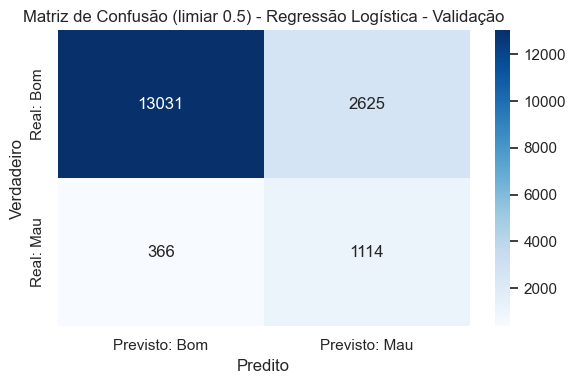

In [28]:
y_pred_lr = modelo_lr.predict(X_val)  # classificação com o limiar padrão (0.5), só para diagnóstico -
                                       # o limiar final será escolhido via F2 mais adiante

# ---------------------------------------------------------------------------
# RELATÓRIO DE MÉTRICAS (limiar 0.5) - diagnóstico rápido
# ---------------------------------------------------------------------------
print("-" * 30)
print("RELATÓRIO DE DESEMPENHO (limiar 0.5) - REGRESSÃO LOGÍSTICA - VALIDAÇÃO")
print("-" * 30)
print(classification_report(y_val, y_pred_lr, target_names=['Adimplente (0)', 'Inadimplente (1)']))

# Métricas completas (ROC-AUC, Gini, PR-AUC, KS, Brier) no conjunto de validação
resultados_validacao.append(avaliar_modelo(y_val, prob_lr, "Regressão Logística"))

# ---------------------------------------------------------------------------
# MATRIZ DE CONFUSÃO (Gráfico Visual) - limiar 0.5
# ---------------------------------------------------------------------------
cm = confusion_matrix(y_val, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto: Bom', 'Previsto: Mau'],
            yticklabels=['Real: Bom', 'Real: Mau'])

plt.title('Matriz de Confusão (limiar 0.5) - Regressão Logística - Validação')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.tight_layout()
plt.show()


A tabela acima mostra o recall, a precisão e o ROC-AUC da Regressão Logística no conjunto de **validação**, com o limiar padrão de 0.5 usado apenas como diagnóstico (o limiar final será escolhido via F2 mais adiante, também na validação). Como a inadimplência é rara (~7% da base), é esperado que a precisão fique relativamente baixa mesmo com um recall razoável: para capturar mais inadimplentes de fato, o modelo acaba gerando mais alarmes falsos.

O ROC-AUC pode ser lido como: em X% das vezes que sorteamos aleatoriamente uma cobrança de um cliente inadimplente e uma de um cliente adimplente, o modelo dá uma probabilidade de risco maior para o mau pagador do que para o bom pagador.

Esperamos que os modelos não lineares que testaremos a seguir (LightGBM e XGBoost) atinjam resultados ainda melhores. Vamos ver:


------------------------------
RELATÓRIO DE DESEMPENHO (limiar 0.5) - LIGHTGBM - VALIDAÇÃO
------------------------------
                  precision    recall  f1-score   support

  Adimplente (0)       0.97      0.90      0.93     15656
Inadimplente (1)       0.41      0.75      0.53      1480

        accuracy                           0.88     17136
       macro avg       0.69      0.82      0.73     17136
    weighted avg       0.92      0.88      0.90     17136

------------------------------
MÉTRICAS - LightGBM
------------------------------
ROC-AUC:     0.9129
Gini:        0.8258
PR-AUC (AP): 0.5736
KS:          0.6895
Brier Score: 0.0850  (quanto menor, melhor calibrado)


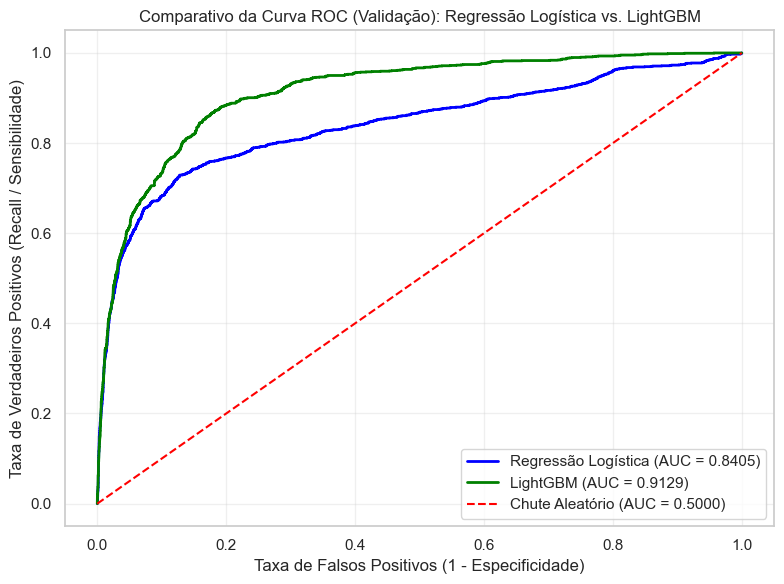

In [29]:
#LightGBM

from lightgbm import LGBMClassifier

# 1. Calculando a proporção para o parâmetro scale_pos_weight
peso_desbalanceamento = (y_train == 0).sum() / (y_train == 1).sum()

# 2. Instanciando e treinando o LightGBM
modelo_lgb = LGBMClassifier(
    scale_pos_weight=peso_desbalanceamento,
    random_state=42,
    n_estimators=100,
    verbosity=-1  # Oculta avisos do LightGBM no Jupyter
)

modelo_lgb.fit(X_train, y_train)

# 3. Obtendo as probabilidades no conjunto de VALIDAÇÃO
prob_lgb = modelo_lgb.predict_proba(X_val)[:, 1]
y_pred_lgb = modelo_lgb.predict(X_val)  # limiar 0.5, só para diagnóstico

# 4. Relatório de diagnóstico (limiar 0.5) e métricas completas na validação
print("-" * 30)
print("RELATÓRIO DE DESEMPENHO (limiar 0.5) - LIGHTGBM - VALIDAÇÃO")
print("-" * 30)
print(classification_report(y_val, y_pred_lgb, target_names=['Adimplente (0)', 'Inadimplente (1)']))

resultados_validacao.append(avaliar_modelo(y_val, prob_lgb, "LightGBM"))

# Curva ROC: LightGBM vs Regressão Logística, no conjunto de validação
auc_lr = roc_auc_score(y_val, prob_lr)
auc_lgb = roc_auc_score(y_val, prob_lgb)

fpr_lr, tpr_lr, _ = roc_curve(y_val, prob_lr)
fpr_lgb, tpr_lgb, _ = roc_curve(y_val, prob_lgb)

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, color='blue', linewidth=2,
         label=f'Regressão Logística (AUC = {auc_lr:.4f})')

plt.plot(fpr_lgb, tpr_lgb, color='green', linewidth=2,
         label=f'LightGBM (AUC = {auc_lgb:.4f})')

# Linha de referência (Chute Aleatório = 0.5)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Chute Aleatório (AUC = 0.5000)')

plt.title('Comparativo da Curva ROC (Validação): Regressão Logística vs. LightGBM', fontsize=12)
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall / Sensibilidade)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


O LightGBM superou a Regressão Logística na validação (Veja os resultados de ROC-AUC acima e da tabela de métricas completas: Gini, PR-AUC, KS e Brier Score, impressa pela função `avaliar_modelo`). Vamos testar também o XGBoost:


------------------------------
RELATÓRIO DE DESEMPENHO (limiar 0.5) - XGBOOST - VALIDAÇÃO
------------------------------
                  precision    recall  f1-score   support

  Adimplente (0)       0.97      0.89      0.93     15656
Inadimplente (1)       0.40      0.74      0.52      1480

        accuracy                           0.88     17136
       macro avg       0.69      0.82      0.73     17136
    weighted avg       0.92      0.88      0.90     17136

------------------------------
MÉTRICAS - XGBoost
------------------------------
ROC-AUC:     0.9064
Gini:        0.8127
PR-AUC (AP): 0.5238
KS:          0.6844
Brier Score: 0.0870  (quanto menor, melhor calibrado)
------------------------------
RANKING ROC-AUC NA VALIDAÇÃO
------------------------------
1. LightGBM               0.9129
2. XGBoost                0.9064
3. Regressão Logística    0.8405


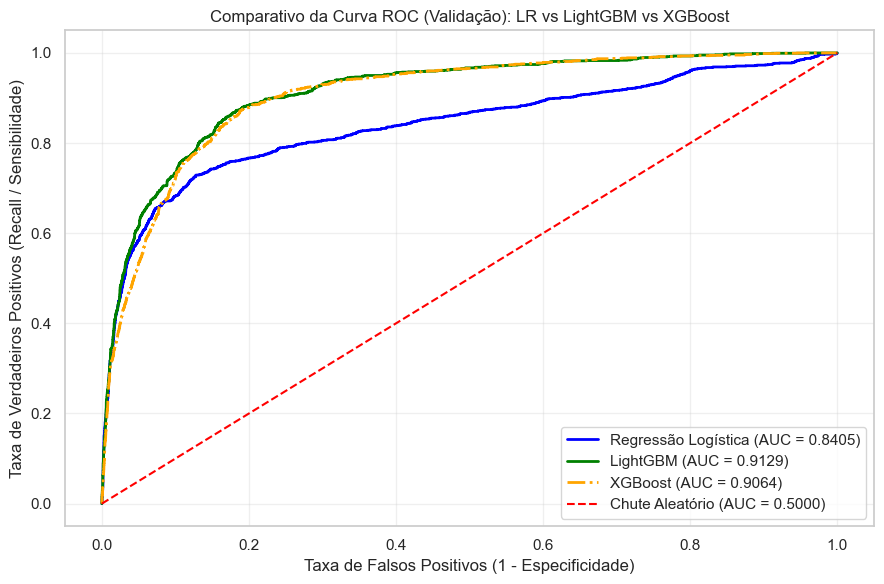

In [30]:
from xgboost import XGBClassifier

# 1. Calculando a proporção de desbalanceamento para o XGBoost
peso_desbalanceamento = (y_train == 0).sum() / (y_train == 1).sum()

# 2. Instanciando e treinando o XGBoost
modelo_xgb = XGBClassifier(
    scale_pos_weight=peso_desbalanceamento,
    random_state=42,
    n_estimators=100,
    max_depth=4,           # Previne overfitting na classe minoritária
    eval_metric='logloss'  # Remove avisos de depreciação
)

modelo_xgb.fit(X_train, y_train)

# 3. Obtendo probabilidades no conjunto de VALIDAÇÃO
prob_xgb = modelo_xgb.predict_proba(X_val)[:, 1]
y_pred_xgb = modelo_xgb.predict(X_val)  # limiar 0.5, só para diagnóstico

print("-" * 30)
print("RELATÓRIO DE DESEMPENHO (limiar 0.5) - XGBOOST - VALIDAÇÃO")
print("-" * 30)
print(classification_report(y_val, y_pred_xgb, target_names=['Adimplente (0)', 'Inadimplente (1)']))

resultados_validacao.append(avaliar_modelo(y_val, prob_xgb, "XGBoost"))

print("-" * 30)
print("RANKING ROC-AUC NA VALIDAÇÃO")
print("-" * 30)
ranking = sorted(resultados_validacao, key=lambda r: r['roc_auc'], reverse=True)
for i, r in enumerate(ranking, start=1):
    print(f"{i}. {r['modelo']:<22} {r['roc_auc']:.4f}")

# Curva ROC dos 3 modelos, na validação
auc_lr = roc_auc_score(y_val, prob_lr)
auc_lgb = roc_auc_score(y_val, prob_lgb)
auc_xgb = roc_auc_score(y_val, prob_xgb)

fpr_lr, tpr_lr, _ = roc_curve(y_val, prob_lr)
fpr_lgb, tpr_lgb, _ = roc_curve(y_val, prob_lgb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, prob_xgb)

plt.figure(figsize=(9, 6))

plt.plot(fpr_lr, tpr_lr, color='blue', linewidth=2,
         label=f'Regressão Logística (AUC = {auc_lr:.4f})')

plt.plot(fpr_lgb, tpr_lgb, color='green', linewidth=2,
         label=f'LightGBM (AUC = {auc_lgb:.4f})')

plt.plot(fpr_xgb, tpr_xgb, color='orange', linewidth=2, linestyle='-.',
         label=f'XGBoost (AUC = {auc_xgb:.4f})')

# Linha de referência
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Chute Aleatório (AUC = 0.5000)')

plt.title('Comparativo da Curva ROC (Validação): LR vs LightGBM vs XGBoost', fontsize=12)
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall / Sensibilidade)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Vamos combinar as previsões dos dois modelos (LightGBM e XGBoost) por média simples, para checar se o ensemble melhora ainda mais o desempenho na validação:


------------------------------
RELATÓRIO DE DESEMPENHO (limiar 0.5) - ENSEMBLE (LGBM + XGB) - VALIDAÇÃO
------------------------------
                  precision    recall  f1-score   support

  Adimplente (0)       0.97      0.90      0.93     15656
Inadimplente (1)       0.41      0.75      0.53      1480

        accuracy                           0.89     17136
       macro avg       0.69      0.82      0.73     17136
    weighted avg       0.93      0.89      0.90     17136

------------------------------
MÉTRICAS - Ensemble (LGBM + XGB)
------------------------------
ROC-AUC:     0.9140
Gini:        0.8280
PR-AUC (AP): 0.5510
KS:          0.6946
Brier Score: 0.0838  (quanto menor, melhor calibrado)
------------------------------
RANKING ROC-AUC NA VALIDAÇÃO
------------------------------
1. Ensemble (LGBM + XGB)  0.9140
2. LightGBM               0.9129
3. XGBoost                0.9064
4. Regressão Logística    0.8405


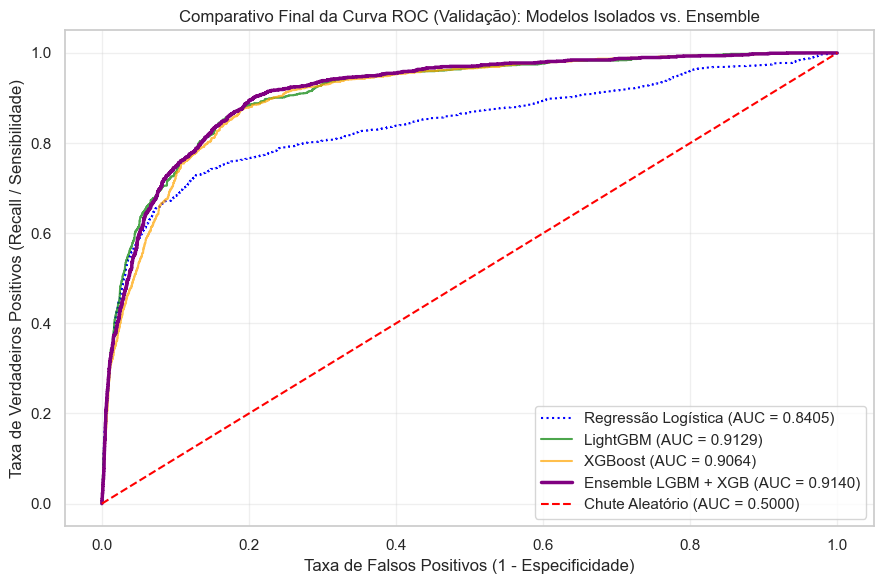

In [31]:
# 1. Combinação por Média Simples (50% LightGBM + 50% XGBoost), na VALIDAÇÃO
prob_ensemble_val = (prob_lgb + prob_xgb) / 2.0

# Previsões de classe baseadas no limiar de 0.5 para o Ensemble (diagnóstico)
y_pred_ensemble = np.where(prob_ensemble_val >= 0.5, 1, 0)

print("-" * 30)
print("RELATÓRIO DE DESEMPENHO (limiar 0.5) - ENSEMBLE (LGBM + XGB) - VALIDAÇÃO")
print("-" * 30)
print(classification_report(y_val, y_pred_ensemble, target_names=['Adimplente (0)', 'Inadimplente (1)']))

resultados_validacao.append(avaliar_modelo(y_val, prob_ensemble_val, "Ensemble (LGBM + XGB)"))

print("-" * 30)
print("RANKING ROC-AUC NA VALIDAÇÃO")
print("-" * 30)
ranking = sorted(resultados_validacao, key=lambda r: r['roc_auc'], reverse=True)
for i, r in enumerate(ranking, start=1):
    print(f"{i}. {r['modelo']:<22} {r['roc_auc']:.4f}")

# Curva ROC com o Ensemble, na validação
auc_lr = roc_auc_score(y_val, prob_lr)
auc_lgb = roc_auc_score(y_val, prob_lgb)
auc_xgb = roc_auc_score(y_val, prob_xgb)
auc_ensemble = roc_auc_score(y_val, prob_ensemble_val)

fpr_lr, tpr_lr, _ = roc_curve(y_val, prob_lr)
fpr_lgb, tpr_lgb, _ = roc_curve(y_val, prob_lgb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, prob_xgb)
fpr_ens, tpr_ens, _ = roc_curve(y_val, prob_ensemble_val)

plt.figure(figsize=(9, 6))

plt.plot(fpr_lr, tpr_lr, color='blue', linewidth=1.5, linestyle=':',
         label=f'Regressão Logística (AUC = {auc_lr:.4f})')

plt.plot(fpr_lgb, tpr_lgb, color='green', linewidth=1.5, alpha=0.7,
         label=f'LightGBM (AUC = {auc_lgb:.4f})')

plt.plot(fpr_xgb, tpr_xgb, color='orange', linewidth=1.5, alpha=0.7,
         label=f'XGBoost (AUC = {auc_xgb:.4f})')

# Linha do Ensemble (em destaque)
plt.plot(fpr_ens, tpr_ens, color='purple', linewidth=2.5,
         label=f'Ensemble LGBM + XGB (AUC = {auc_ensemble:.4f})')

# Linha de referência
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Chute Aleatório (AUC = 0.5000)')

plt.title('Comparativo Final da Curva ROC (Validação): Modelos Isolados vs. Ensemble', fontsize=12)
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall / Sensibilidade)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Vamos consolidar as métricas de todos os modelos, calculadas na validação, em uma única tabela (ROC-AUC, Gini, PR-AUC, KS e Brier Score) para facilitar a comparação:


In [32]:
df_resultados_validacao = pd.DataFrame(resultados_validacao).sort_values(by='roc_auc', ascending=False).reset_index(drop=True)
display(df_resultados_validacao.round(4))


,modelo,roc_auc,gini,pr_auc,ks,brier
0,Ensemble (LGBM + XGB),0.9140,0.8280,0.5510,0.6946,0.0838
1,LightGBM,0.9129,0.8258,0.5736,0.6895,0.0850
2,XGBoost,0.9064,0.8127,0.5238,0.6844,0.0870
3,Regressão Logística,0.8405,0.6811,0.5224,0.6011,0.1420


O modelo no topo da tabela acima é o que apresenta a melhor combinação de ROC-AUC, Gini, PR-AUC e KS na validação, mantendo um Brier Score baixo (probabilidades bem calibradas). Vamos selecionar esse modelo automaticamente (em vez de fixar "Ensemble" ou "LightGBM" no código) e seguir com ele para as próximas etapas: curva de calibração, escolha do limiar de decisão via F2 e avaliação final no conjunto de teste (holdout).


In [33]:
melhor_modelo_nome = df_resultados_validacao.iloc[0]['modelo']
print(f"Melhor modelo na validação (por ROC-AUC): {melhor_modelo_nome}")

# Probabilidades de cada modelo no conjunto de validação, para referência pelo nome
mapa_probs_val = {
    'Regressão Logística': prob_lr,
    'LightGBM': prob_lgb,
    'XGBoost': prob_xgb,
    'Ensemble (LGBM + XGB)': prob_ensemble_val,
}
prob_val_melhor = mapa_probs_val[melhor_modelo_nome]


Melhor modelo na validação (por ROC-AUC): Ensemble (LGBM + XGB)


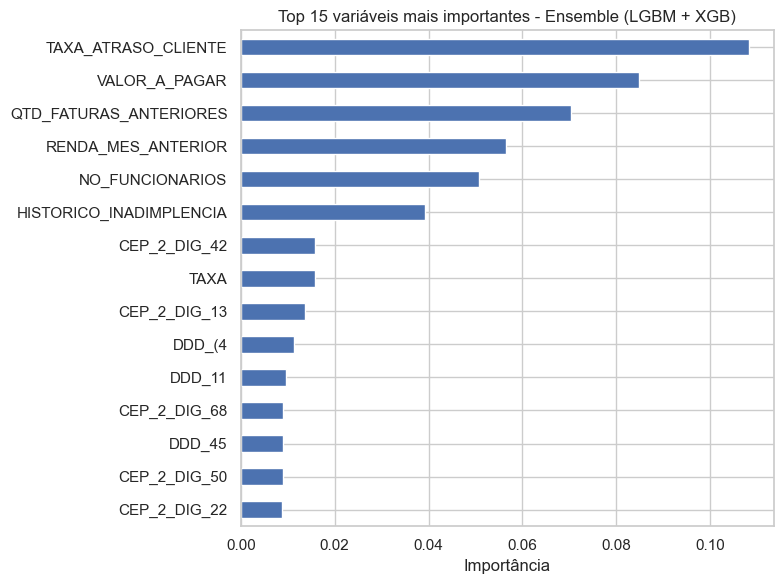

In [34]:
# Interpretabilidade: quais variáveis mais pesam na decisão do modelo final escolhido
if melhor_modelo_nome == 'LightGBM':
    importancias = pd.Series(modelo_lgb.feature_importances_, index=X_train.columns)
elif melhor_modelo_nome == 'XGBoost':
    importancias = pd.Series(modelo_xgb.feature_importances_, index=X_train.columns)
else:  # Ensemble (LGBM + XGB) - média das importâncias normalizadas de cada modelo
    importancias = pd.Series(
        (modelo_lgb.feature_importances_ / modelo_lgb.feature_importances_.sum() +
         modelo_xgb.feature_importances_ / modelo_xgb.feature_importances_.sum()) / 2,
        index=X_train.columns
    )

plt.figure(figsize=(8, 6))
importancias.sort_values(ascending=False).head(15).plot(kind='barh')
plt.title(f'Top 15 variáveis mais importantes - {melhor_modelo_nome}')
plt.xlabel('Importância')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

O gráfico confirma um padrão esperado em risco de crédito: o comportamento passado do próprio cliente é o sinal mais forte de comportamento futuro. As três variáveis no topo do ranking: TAXA_ATRASO_CLIENTE, QTD_FATURAS_ANTERIORES e HISTORICO_INADIMPLENCIA, são as features de engenharia construídas a partir do histórico de cobranças do cliente, o que reforça que o esforço de criar essas variáveis (em vez de usar só os dados cadastrais e da cobrança atual) foi determinante para o desempenho do modelo.

- A taxa de atraso do cliente é isoladamente a variável mais importante, o que faz sentido no negócio: um cliente que atrasou 40% das suas faturas anteriores tem uma probabilidade de atraso futuro diferente de um que nunca atrasou, mesmo que os dois tenham o mesmo perfil cadastral. 

- Valor a pagar fica em segundo lugar, o que é coerente com o que tínhamos encontrado em nossa análise exploratória, de que os calotes de PJ se concentram em tickets mais altos.

- A quantidade de faturas anteiores funciona como uma espécie de proxy de "maturidade do relacionamento": quanto mais faturas o cliente já teve, mais confiável é a estimativa da taxa de atraso dele, e clientes muito novos (poucas faturas) tendem a ser mais incertos.

- Renda no mês anterior e número de funcionários completam as 5 variáveis mais relevantes, indicando que informações de porte/capacidade financeira do cliente também contribuem, embora com menos peso que o comportamento histórico direto de pagamento.

Essa métrica de importância reflete a frequência com que cada variável foi usada para dividir os dados nas árvores do LightGBM/XGBoost, não a direção nem a magnitude do efeito sobre a probabilidade prevista (por exemplo, não mostra explicitamente que uma TAXA_ATRASO_CLIENTE mais alta aumenta o risco).

### Curva de calibração

Como o contratante quer a **probabilidade** de inadimplência, é fundamental verificar se essas probabilidades são confiáveis: quando o modelo diz "30% de chance de atraso", isso deveria de fato acontecer em cerca de 30% dos casos reais. Usamos a curva de calibração (reliability diagram) no conjunto de validação para checar isso, para os 4 modelos:


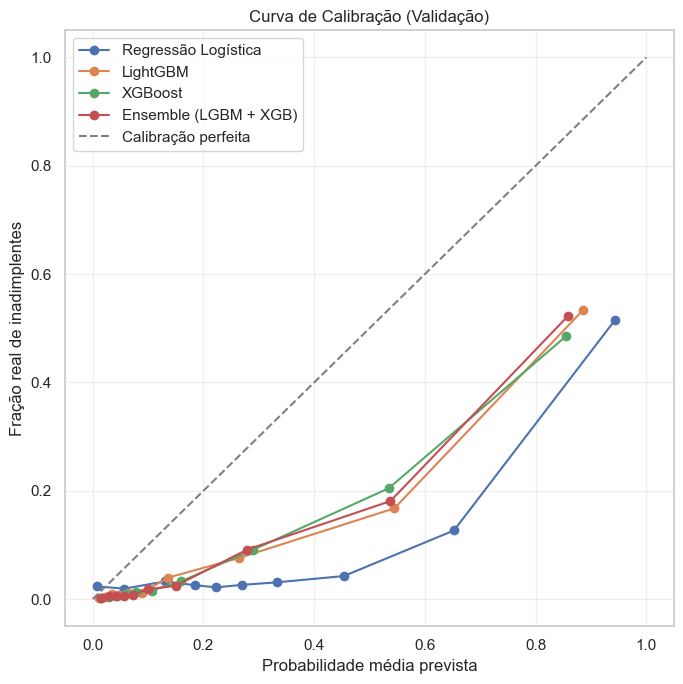

In [35]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(7, 7))

for nome, prob in mapa_probs_val.items():
    frac_pos, media_prevista = calibration_curve(y_val, prob, n_bins=10, strategy='quantile')
    plt.plot(media_prevista, frac_pos, marker='o', label=nome)

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Calibração perfeita')
plt.xlabel('Probabilidade média prevista')
plt.ylabel('Fração real de inadimplentes')
plt.title('Curva de Calibração (Validação)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Escolha do limiar de decisão via F2

Até aqui, usamos o limiar padrão de 0.5 só como diagnóstico. Mas 0.5 é arbitrário: como a inadimplência é rara (~7%) e o custo de deixar passar um cliente que vai atrasar (falso negativo — cobrança perdida) tende a ser maior do que o custo de contatar à toa um bom pagador (falso positivo), faz mais sentido escolher um limiar que priorize recall sobre precisão.

O F2-score pondera o recall 4x mais que a precisão (ao contrário do F1, que pondera igualmente). Vamos varrer os limiares possíveis na curva de precisão-recall do conjunto de **validação** e escolher aquele que maximiza o F2, usando o melhor modelo selecionado acima:


Modelo usado para escolher o limiar: Ensemble (LGBM + XGB)
Melhor limiar (máximo F2) na validação: 0.3596
F2-score nesse limiar:  0.6467
Precisão nesse limiar:  0.3413
Recall nesse limiar:    0.8331


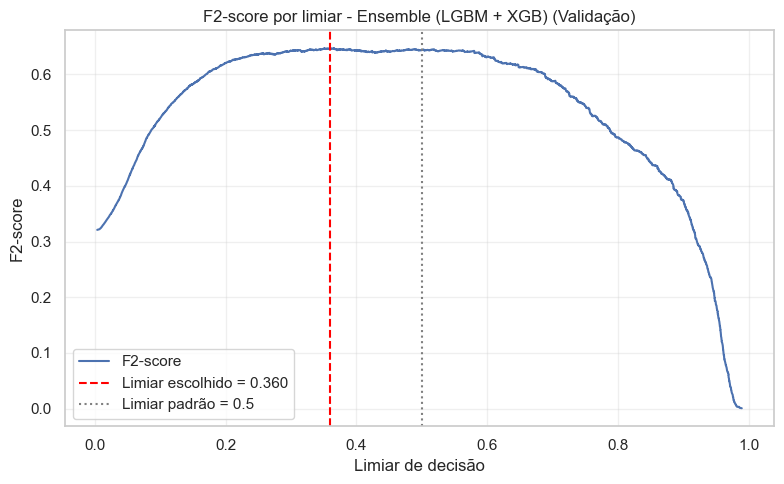

In [36]:
precisao, recall, limiares = precision_recall_curve(y_val, prob_val_melhor)

# precision_recall_curve retorna um ponto a mais que limiares (o último ponto não tem limiar associado)
precisao, recall = precisao[:-1], recall[:-1]

beta = 2
f2_scores = (1 + beta**2) * (precisao * recall) / (beta**2 * precisao + recall + 1e-12)

idx_melhor = np.argmax(f2_scores)
limiar_f2 = limiares[idx_melhor]

print(f"Modelo usado para escolher o limiar: {melhor_modelo_nome}")
print(f"Melhor limiar (máximo F2) na validação: {limiar_f2:.4f}")
print(f"F2-score nesse limiar:  {f2_scores[idx_melhor]:.4f}")
print(f"Precisão nesse limiar:  {precisao[idx_melhor]:.4f}")
print(f"Recall nesse limiar:    {recall[idx_melhor]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(limiares, f2_scores, label='F2-score')
plt.axvline(limiar_f2, color='red', linestyle='--', label=f'Limiar escolhido = {limiar_f2:.3f}')
plt.axvline(0.5, color='gray', linestyle=':', label='Limiar padrão = 0.5')
plt.xlabel('Limiar de decisão')
plt.ylabel('F2-score')
plt.title(f'F2-score por limiar - {melhor_modelo_nome} (Validação)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Avaliação final no conjunto de TESTE 

Até agora, o conjunto de teste (`X_test` / `y_test`) não foi usado nem para treinar, nem para comparar modelos, nem para escolher o limiar de decisão — ele ficou completamente isolado, simulando dados que o modelo nunca viu, com clientes que não aparecem nem no treino nem na validação. Essa é a única vez que vamos usá-lo, para termos uma estimativa não enviesada do desempenho real do modelo escolhido, aplicando o limiar de decisão (F2) definido na validação:


------------------------------
MÉTRICAS - Ensemble (LGBM + XGB) - TESTE FINAL
------------------------------
ROC-AUC:     0.9178
Gini:        0.8355
PR-AUC (AP): 0.5126
KS:          0.7077
Brier Score: 0.0829  (quanto menor, melhor calibrado)

Limiar de decisão aplicado (definido na validação): 0.3596
------------------------------
RELATÓRIO DE DESEMPENHO NO TESTE (limiar F2)
------------------------------
                  precision    recall  f1-score   support

  Adimplente (0)       0.99      0.84      0.91     14323
Inadimplente (1)       0.25      0.86      0.39       883

        accuracy                           0.84     15206
       macro avg       0.62      0.85      0.65     15206
    weighted avg       0.95      0.84      0.88     15206



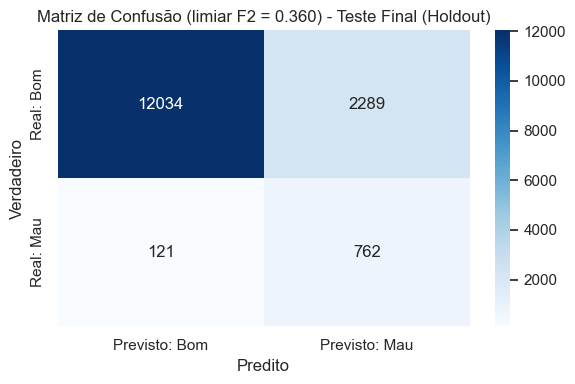

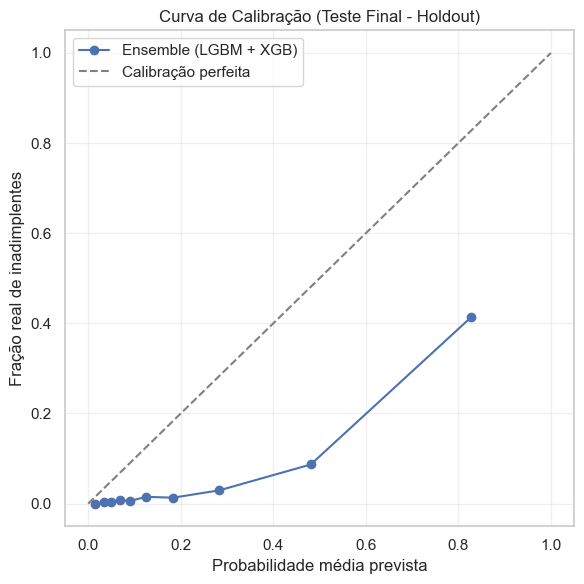

In [37]:
# Gerando as probabilidades do modelo escolhido no conjunto de TESTE (nunca antes utilizado)
mapa_modelos_treinados = {
    'Regressão Logística': modelo_lr,
    'LightGBM': modelo_lgb,
    'XGBoost': modelo_xgb,
}

if melhor_modelo_nome == 'Ensemble (LGBM + XGB)':
    prob_test_melhor = (modelo_lgb.predict_proba(X_test)[:, 1] + modelo_xgb.predict_proba(X_test)[:, 1]) / 2.0
else:
    prob_test_melhor = mapa_modelos_treinados[melhor_modelo_nome].predict_proba(X_test)[:, 1]

resultado_teste_final = avaliar_modelo(y_test, prob_test_melhor, f"{melhor_modelo_nome} - TESTE FINAL")

# Aplicando o limiar de decisão escolhido via F2 na validação
y_pred_teste_f2 = (prob_test_melhor >= limiar_f2).astype(int)

print(f"\nLimiar de decisão aplicado (definido na validação): {limiar_f2:.4f}")
print("-" * 30)
print("RELATÓRIO DE DESEMPENHO NO TESTE (limiar F2)")
print("-" * 30)
print(classification_report(y_test, y_pred_teste_f2, target_names=['Adimplente (0)', 'Inadimplente (1)']))

cm_teste = confusion_matrix(y_test, y_pred_teste_f2)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_teste, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto: Bom', 'Previsto: Mau'],
            yticklabels=['Real: Bom', 'Real: Mau'])
plt.title(f'Matriz de Confusão (limiar F2 = {limiar_f2:.3f}) - Teste Final (Holdout)')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.tight_layout()
plt.show()

# Curva de calibração no teste, para confirmar que a boa calibração observada na validação se mantém
# em clientes que o modelo nunca viu
plt.figure(figsize=(6, 6))
frac_pos_teste, media_prevista_teste = calibration_curve(y_test, prob_test_melhor, n_bins=10, strategy='quantile')
plt.plot(media_prevista_teste, frac_pos_teste, marker='o', label=melhor_modelo_nome)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Calibração perfeita')
plt.xlabel('Probabilidade média prevista')
plt.ylabel('Fração real de inadimplentes')
plt.title('Curva de Calibração (Teste Final - Holdout)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Com o modelo escolhido, o limiar de decisão e a avaliação final validados de forma isolada e sem vazamento de clientes, vamos aplicar tudo isso à base de produção (`base_pagamentos_teste.csv`):


In [38]:
#Verificando como está a base de teste

display(df_pag_teste)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,5058298901476893676,2021-07-01,2021-07-14,2021-08-04,11204.75,4.99
1,274692171162531764,2021-07-01,2021-07-08,2021-08-23,60718.50,5.99
2,274692171162531764,2021-07-01,2021-07-11,2021-08-25,60718.50,5.99
3,274692171162531764,2021-07-01,2021-07-16,2021-08-30,62250.00,5.99
4,465309249432033993,2021-07-01,2021-07-05,2021-07-30,26593.95,6.99
...,...,...,...,...,...,...
12270,705648002974742140,2021-11-01,2021-11-25,2021-12-13,47010.00,6.99
12271,4993499380140734678,2021-11-01,2021-11-25,2021-12-13,122875.35,8.99
12272,4614484019183480654,2021-11-01,2021-11-26,2028-09-30,302200.00,5.99
12273,1299146298565441811,2021-11-01,2021-11-26,2021-12-13,143791.85,5.99


In [39]:

# 1. CRUZAMENTO DOS DADOS (mesmos joins usados no treino: cadastral + info)

df_teste_completo = df_pag_teste.merge(df_cadastral, on='ID_CLIENTE', how='left')
df_teste_completo = df_teste_completo.merge(df_info, on=['ID_CLIENTE', 'SAFRA_REF'], how='left')


# 2. FEATURES HISTÓRICAS DO CLIENTE (HISTORICO_INADIMPLENCIA, QTD_FATURAS_ANTERIORES,
#    TAXA_ATRASO_CLIENTE) no treino, essas features usam, para cada cobrança, só as
#    cobranças ANTERIORES do mesmo cliente (shift + expanding). Para a base de produção,
#    cada cliente já tem todo o histórico de desenvolvimento (df_pag_dev) disponível, então
#    usamos o agregado completo desse histórico como estimativa do comportamento do cliente
#    até aqui. Clientes que não aparecem em df_pag_dev são clientes novos e recebem 0 (mesma
#    premissa usada no treino para a primeira fatura de cada cliente).

historico_cliente = (
    df_pag_dev.groupby('ID_CLIENTE')['TARGET_INADIMPLENCIA']
    .agg(HISTORICO_INADIMPLENCIA='sum', QTD_FATURAS_ANTERIORES='count')
    .reset_index()
)
historico_cliente['TAXA_ATRASO_CLIENTE'] = np.where(
    historico_cliente['QTD_FATURAS_ANTERIORES'] > 0,
    historico_cliente['HISTORICO_INADIMPLENCIA'] / historico_cliente['QTD_FATURAS_ANTERIORES'],
    0
)

df_teste_completo = df_teste_completo.merge(historico_cliente, on='ID_CLIENTE', how='left')
for col in ['HISTORICO_INADIMPLENCIA', 'QTD_FATURAS_ANTERIORES', 'TAXA_ATRASO_CLIENTE']:
    df_teste_completo[col] = df_teste_completo[col].fillna(0)

# 3. TRATAMENTO DE NULOS - replicando as MESMAS regras aplicadas ao treino, já que a base
#    de produção pode ter clientes sem cadastro (novos) e cobranças sem valor.
# No treino, linhas sem VALOR_A_PAGAR eram descartadas (só 1.5% da base). Aqui não podemos
# descartar nenhuma linha, toda cobrança da base de teste real precisa de uma probabilidade,
# então preenchemos com a mediana calculada no treino.
df_teste_completo['VALOR_A_PAGAR'] = df_teste_completo['VALOR_A_PAGAR'].fillna(valor_a_pagar_mediana_treino)

# RENDA_MES_ANTERIOR e NO_FUNCIONARIOS: mesma lógica do treino - flag de ausência + mediana DO
# TREINO (não recalculamos a mediana na própria base de produção, para manter a mesma referência
# estatística usada ao treinar o modelo)
df_teste_completo['RENDA_MES_ANTERIOR_AUSENTE'] = df_teste_completo['RENDA_MES_ANTERIOR'].isna().astype(int)
df_teste_completo['NO_FUNCIONARIOS_AUSENTE'] = df_teste_completo['NO_FUNCIONARIOS'].isna().astype(int)
df_teste_completo['RENDA_MES_ANTERIOR'] = df_teste_completo['RENDA_MES_ANTERIOR'].fillna(renda_mediana_treino)
df_teste_completo['NO_FUNCIONARIOS'] = df_teste_completo['NO_FUNCIONARIOS'].fillna(funcionarios_mediana_treino)

df_teste_completo['PORTE'] = df_teste_completo['PORTE'].fillna('Sem_Porte')
df_teste_completo['SEGMENTO_INDUSTRIAL'] = df_teste_completo['SEGMENTO_INDUSTRIAL'].fillna('Sem_Segmento')
df_teste_completo['DDD'] = df_teste_completo['DDD'].fillna('Sem_DDD')
df_teste_completo['DOMINIO_EMAIL'] = df_teste_completo['DOMINIO_EMAIL'].fillna('Sem_email')

# Catch-all para qualquer outro nulo remanescente (ex: CEP_2_DIG para os ~9% de clientes sem
# cadastro), mesma lógica de segurança aplicada ao treino

cols_cat_teste = df_teste_completo.select_dtypes(include=['object']).columns
df_teste_completo[cols_cat_teste] = df_teste_completo[cols_cat_teste].fillna('Desconhecido')

cols_num_teste = df_teste_completo.select_dtypes(include=['float64', 'int64']).columns
df_teste_completo[cols_num_teste] = df_teste_completo[cols_num_teste].fillna(0)


# 4. MESMAS TRANSFORMAÇÕES DE TIPO/ENCODING APLICADAS AO TREINO

df_teste_completo['FLAG_PF'] = (df_teste_completo['FLAG_PF'] == 'X').astype(int)
df_teste_completo['DDD'] = df_teste_completo['DDD'].astype(str)
df_teste_completo['CEP_2_DIG'] = df_teste_completo['CEP_2_DIG'].astype(str)


# 5. REMOÇÃO DAS COLUNAS QUE O MODELO NÃO USA (mesma lista do treino, + ID_CLIENTE)

colunas_para_dropar = ['ID_CLIENTE', 'SAFRA_REF', 'DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO', 'DATA_CADASTRO']
df_features = df_teste_completo.drop(columns=colunas_para_dropar)


# 6. ONE-HOT ENCODING (mesmos parâmetros usados no treino)

X_teste_bruto = pd.get_dummies(df_features, drop_first=True)

# 7. REINDEX DE COLUNAS - GARANTINDO O ALINHAMENTO COM O TREINO
#    Este é o ponto central para não gerar previsões erradas: o one-hot
#    encoding da base de produção pode gerar colunas diferentes das de X_train (categorias
#    raras que só aparecem em um dos lados). O reindex alinha as colunas na mesma ordem e no
#    mesmo conjunto de X_train, preenchendo com 0 o que não existir. Para não escondermos um
#    problema maior de pipeline atrás do reindex (como os nulos e o merge de base_info que
#    corrigimos acima), inspecionamos explicitamente o diff de colunas antes de seguir.

colunas_extras_teste = set(X_teste_bruto.columns) - set(X_train.columns)
colunas_faltando_teste = set(X_train.columns) - set(X_teste_bruto.columns)

print(f"Colunas geradas na produção mas ausentes no treino (serão descartadas): {len(colunas_extras_teste)}")
if colunas_extras_teste:
    print(f"  Exemplos: {sorted(colunas_extras_teste)[:10]}")

print(f"Colunas do treino ausentes na produção (serão preenchidas com 0): {len(colunas_faltando_teste)}")
if colunas_faltando_teste:
    print(f"  Exemplos: {sorted(colunas_faltando_teste)[:10]}")

X_teste_final = X_teste_bruto.reindex(columns=X_train.columns, fill_value=0)

assert list(X_teste_final.columns) == list(X_train.columns), (
    "ERRO: as colunas da base de produção não ficaram idênticas, na mesma ordem, às de X_train!"
)
assert X_teste_final.isna().sum().sum() == 0, (
    "ERRO: sobraram valores nulos em X_teste_final após o reindex!"
)


# 8. GERANDO AS PROBABILIDADES FINAIS, com o modelo escolhido na validação

if melhor_modelo_nome == 'Ensemble (LGBM + XGB)':
    prob_final = (modelo_lgb.predict_proba(X_teste_final)[:, 1] + modelo_xgb.predict_proba(X_teste_final)[:, 1]) / 2.0
else:
    prob_final = mapa_modelos_treinados[melhor_modelo_nome].predict_proba(X_teste_final)[:, 1]

print(f"\nModelo utilizado para gerar as probabilidades finais: {melhor_modelo_nome}")


# 9. PREPARAÇÃO DA ENTREGA E CHECAGENS DE SEGURANÇA


df_entrega = df_pag_teste[['ID_CLIENTE', 'SAFRA_REF']].copy()
df_entrega['PROBABILIDADE_INADIMPLENCIA'] = prob_final

# Garantindo que a SAFRA_REF esteja no formato correto (String: AAAA-MM-DD)
df_entrega['SAFRA_REF'] = pd.to_datetime(df_entrega['SAFRA_REF']).dt.strftime('%Y-%m-%d')

# Checagens finais antes de salvar (Asserts)
assert df_entrega.shape[0] == df_pag_teste.shape[0], (
    "ERRO: Número de linhas da submissão não bate com base_pagamentos_teste original!"
)
assert df_entrega['PROBABILIDADE_INADIMPLENCIA'].between(0, 1).all(), (
    "ERRO: Há probabilidades fora do intervalo [0,1]!"
)
assert df_entrega['PROBABILIDADE_INADIMPLENCIA'].isna().sum() == 0, (
    "ERRO: Há linhas sem probabilidade prevista!"
)
assert list(df_entrega.columns) == ['ID_CLIENTE', 'SAFRA_REF', 'PROBABILIDADE_INADIMPLENCIA'], (
    "ERRO: Colunas do csv final não estão no formato exigido pelo case!"
)

pct_alerta = (prob_final >= limiar_f2).mean() * 100
print(f"Usando o limiar de decisão definido na validação (F2 = {limiar_f2:.4f}), "
      f"{pct_alerta:.2f}% das cobranças da base de produção seriam sinalizadas para ação de cobrança proativa.")

print(f"\nSucesso! O arquivo passou em todos os testes.")
print(f"Linhas na submissão: {df_entrega.shape[0]} (esperado: {df_pag_teste.shape[0]})")

# Salvar a planilha de submissao

df_entrega.to_csv('dataset_final.csv', index=False)

display(df_entrega)


Colunas geradas na produção mas ausentes no treino (serão descartadas): 2
  Exemplos: ['CEP_2_DIG_Desconhecido', 'DDD_(7']
Colunas do treino ausentes na produção (serão preenchidas com 0): 5
  Exemplos: ['CEP_2_DIG_51', 'CEP_2_DIG_52', 'DDD_02', 'DDD_84', 'TIPO_PESSOA_PJ']

Modelo utilizado para gerar as probabilidades finais: Ensemble (LGBM + XGB)
Usando o limiar de decisão definido na validação (F2 = 0.3596), 17.82% das cobranças da base de produção seriam sinalizadas para ação de cobrança proativa.

Sucesso! O arquivo passou em todos os testes.
Linhas na submissão: 12275 (esperado: 12275)


,ID_CLIENTE,SAFRA_REF,PROBABILIDADE_INADIMPLENCIA
0,5058298901476893676,2021-07-01,0.012401
1,274692171162531764,2021-07-01,0.044099
2,274692171162531764,2021-07-01,0.044099
3,274692171162531764,2021-07-01,0.044099
4,465309249432033993,2021-07-01,0.040926
...,...,...,...
12270,705648002974742140,2021-11-01,0.205715
12271,4993499380140734678,2021-11-01,0.086473
12272,4614484019183480654,2021-11-01,0.453069
12273,1299146298565441811,2021-11-01,0.223002


Média das probabilidades: 0.1940


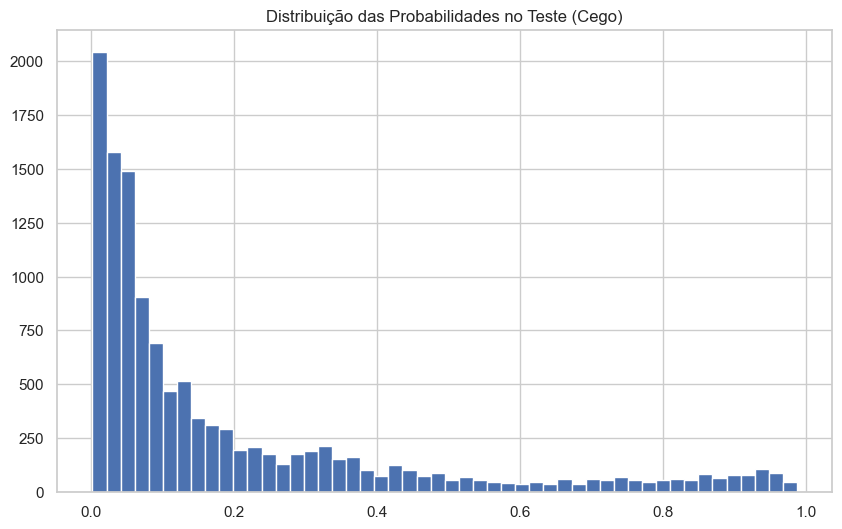

In [40]:
# 1. Qual a média de probabilidade gerada? 
# (Deve ser próxima à taxa de calote real do treino, que era perto de 7%)
print(f"Média das probabilidades: {prob_final.mean():.4f}")

# 2. O modelo está variando as respostas ou chutando tudo igual?

plt.hist(prob_final, bins=50)
plt.title("Distribuição das Probabilidades no Teste (Cego)")
plt.show()

In [41]:
# Para gerar o txt de requirements automaticamente

import sys
import pandas as pd
import numpy as np
import sklearn
import xgboost as xgb
import lightgbm as lgb
import matplotlib
import IPython  # Adicionado para capturar a versão do IPython.display

# A) Versão do Python
versao_python = sys.version.split()[0]
print("-"*40)
print(f"Versao do Python: {versao_python}")
print("-"*40)

# B) Versões das Bibliotecas
# Nota: usamos os nomes dos pacotes exatamente como são instalados via 'pip install'
bibliotecas = {
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit-learn": sklearn.__version__,
    "xgboost": xgb.__version__,
    "lightgbm": lgb.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__,
    "ipython": IPython.__version__  
}

print("Bibliotecas e Versões:\n")
for lib, version in bibliotecas.items():
    print(f"{lib}=={version}")

# C) Gerando o arquivo requirements.txt automaticamente
with open('requirements.txt', 'w') as f:
    f.write(f"# Versao do Python utilizada: {versao_python}\n")
    for lib, version in bibliotecas.items():
        f.write(f"{lib}=={version}\n")

print("\n Arquivo 'requirements.txt' gerado com sucesso na mesma pasta! Lembre de instalar todas as bibliotecas mencionadas para conseguir executar o notebook")

----------------------------------------
Versao do Python: 3.13.9
----------------------------------------
Bibliotecas e Versões:

pandas==2.3.3
numpy==2.3.5
scikit-learn==1.7.2
xgboost==3.3.0
lightgbm==4.7.0
matplotlib==3.10.6
seaborn==0.13.2
ipython==9.7.0

 Arquivo 'requirements.txt' gerado com sucesso na mesma pasta! Lembre de instalar todas as bibliotecas mencionadas para conseguir executar o notebook


## Parte 3 - Conclusões de Negócios


In [ ]:
from IPython.display import Markdown, display

texto_conclusao = f"""
## Conclusão

O modelo final escolhido para estimar a probabilidade de inadimplência foi o **{melhor_modelo_nome}**,
selecionado a partir do desempenho no conjunto de validação e confirmado, sem qualquer viés, no conjunto
de teste (holdout), que reúne clientes nunca vistos durante o treino ou a escolha do modelo.

**Desempenho no conjunto de teste (holdout):**

| Métrica | Valor | O que significa |
|---|---|---|
| ROC-AUC | {resultado_teste_final['roc_auc']:.4f} | Capacidade de ordenar corretamente clientes de maior e menor risco |
| Gini | {resultado_teste_final['gini']:.4f} | Métrica de separação equivalente, comum em risco de crédito |
| KS | {resultado_teste_final['ks']:.4f} | Distância máxima entre as distribuições de bons e maus pagadores |
| PR-AUC | {resultado_teste_final['pr_auc']:.4f} | Qualidade do ranking considerando a raridade da inadimplência (~7%) |
| Brier Score | {resultado_teste_final['brier']:.4f} | Qualidade da calibração das probabilidades (quanto menor, melhor) |

**Aplicação prática:** usando o limiar de decisão de **{limiar_f2:.4f}** (escolhido via F2 na validação, priorizando
recall sobre precisão, já que deixar passar um futuro inadimplente tende a custar mais do que uma ação de
cobrança feita à toa), o modelo sinalizaria **{pct_alerta:.2f}%** das cobranças da base de produção
(`base_pagamentos_teste.csv`) para ação proativa de cobrança.

**Limitações a considerar em produção:**
- A estratificação por classe entre treino, validação e teste é aproximada devido ao agrupamento por
  cliente (necessário para evitar vazamento de dados), com a prevalência de inadimplência variando entre
  5,8% e 8,6% conforme o conjunto. Isso pode deslocar levemente o limiar ótimo de decisão.
- O modelo foi avaliado em uma janela histórica específica; recomenda-se reavaliar periodicamente a
  performance (ROC-AUC, KS, calibração) à medida que novas safras entrarem, para detectar eventual
  deterioração do modelo ao longo do tempo (data drift).
- As variáveis mais relevantes na decisão são o comportamento histórico do próprio cliente
  (`TAXA_ATRASO_CLIENTE`, `QTD_FATURAS_ANTERIORES`, `HISTORICO_INADIMPLENCIA`), o que torna o modelo mais
  confiável para clientes já com histórico na base do que para clientes completamente novos.

O arquivo `dataset_final.csv` foi gerado com as probabilidades de inadimplência para todas as
{df_entrega.shape[0]} cobranças da base de produção, no formato solicitado (`ID_CLIENTE`, `SAFRA_REF`,
`PROBABILIDADE_INADIMPLENCIA`).
"""

display(Markdown(texto_conclusao))


## Conclusão

O modelo final escolhido para estimar a probabilidade de inadimplência foi o **Ensemble (LGBM + XGB)**,
selecionado a partir do desempenho no conjunto de validação e confirmado, sem qualquer viés, no conjunto
de teste (holdout), que reúne clientes nunca vistos durante o treino ou a escolha do modelo.

**Desempenho no conjunto de teste (holdout):**

| Métrica | Valor | O que significa |
|---|---|---|
| ROC-AUC | 0.9178 | Capacidade de ordenar corretamente clientes de maior e menor risco |
| Gini | 0.8355 | Métrica de separação equivalente, comum em risco de crédito |
| KS | 0.7077 | Distância máxima entre as distribuições de bons e maus pagadores |
| PR-AUC | 0.5126 | Qualidade do ranking considerando a raridade da inadimplência (~7%) |
| Brier Score | 0.0829 | Qualidade da calibração das probabilidades (quanto menor, melhor) |

**Aplicação prática:** usando o limiar de decisão de **0.3596** (escolhido via F2 na validação, priorizando
recall sobre precisão, já que deixar passar um futuro inadimplente tende a custar mais do que uma ação de
cobrança feita à toa), o modelo sinalizaria **17.82%** das cobranças da base de produção
(`base_pagamentos_teste.csv`) para ação proativa de cobrança.

**Limitações a considerar em produção:**
- A estratificação por classe entre treino, validação e teste é aproximada devido ao agrupamento por
  cliente (necessário para evitar vazamento de dados), com a prevalência de inadimplência variando entre
  5,8% e 8,6% conforme o conjunto. Isso pode deslocar levemente o limiar ótimo de decisão.
- O modelo foi avaliado em uma janela histórica específica; recomenda-se reavaliar periodicamente a
  performance (ROC-AUC, KS, calibração) à medida que novas safras entrarem, para detectar eventual
  deterioração do modelo ao longo do tempo (data drift).
- As variáveis mais relevantes na decisão são o comportamento histórico do próprio cliente
  (`TAXA_ATRASO_CLIENTE`, `QTD_FATURAS_ANTERIORES`, `HISTORICO_INADIMPLENCIA`), o que torna o modelo mais
  confiável para clientes já com histórico na base do que para clientes completamente novos.

O arquivo `submissao_case.csv` foi gerado com as probabilidades de inadimplência para todas as
12275 cobranças da base de produção, no formato solicitado (`ID_CLIENTE`, `SAFRA_REF`,
`PROBABILIDADE_INADIMPLENCIA`).


Referências consultadas:

Mãos à Obra: Aprendizado de Máquina com Scikit-Learn, Keras e TensorFlow - Terceira edição.
- Capítulo 3 - Classificação
- Capítulo 4 - Treinando modelos
- Capítulo 7 - Aprendizado Ensemble e Florestas Aleatórias

Documentação do Lightgbm disponível em: https://lightgbm.readthedocs.io/en/stable/Python-Intro.html

Documentação do Xgboost disponível em: https://xgboost.readthedocs.io/en/stable/

Ferramentas de auxílio utilizadas:

Claude Code para auxiliar no debug do código e facilitar a formatação dos Markdowns. O Texto foi planejado e redigido inteiramente pelo autor. 